<a href="https://colab.research.google.com/github/alessandropessoa/ciencia-de-Dados/blob/main/segmentacao_mineracao_dados_2025.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Autores

- Alessandro Pesso da da Conceição Barreto (M048.224.002)
- Willam Machado Guimarães

# Ètica, Proveniência e Governança

Como copiloto do workflow, utilizou-se o Prompt Engine com Gemini e ChaGPT, aplicando especificamente a técnica de Role Prompt (RP) conforme descrita por Santana Jr. et al.. Essa abordagem permitiu orientar o modelo com papéis bem definidos, garantindo respostas mais alinhadas ao contexto e aos objetivos do processo. Todo o processo funcionou em um loop de validação e correção humana, onde nós intervimos orientando para os objetivos desejados.

Para assegurar um mínimo de proveniência, rastreabilidade e governança, adotou-se o MLflow. Com ele foi possível registrar e versionar cada etapa do pipeline — desde o processamento, passando pelos experimentos e métricas, até os diferentes stages do modelo. Isso facilita a manutenção, a expansão futura e a revisão estruturada de todo o fluxo de trabalho, criando uma base sólida para auditoria e evolução contínua do sistema.

# Trabalhos Futuros

Refinar o pipeline considerando estratégias de retreinamento, avaliando a viabilidade e os trade-offs envolvidos na validação dos clusters com base em critérios internos. Além disso, investigar o uso de técnicas de desaprendizado de máquina, em especial o método SISA, de modo a permitir que o retreinamento em cenários de degradação do modelo seja executado apenas nos shards relevantes ou, quando necessário, no conjunto completo de dados. Essa abordagem pode reduzir de forma significativa a pegada de carbono e contribuir para práticas de Green AI, além de facilitar a remoção de instâncias problemáticas sem demandar um retreinamento integral do modelo.

Adicionalmente, recomenda-se explorar técnicas baseadas em modelos de representação neural via embeddings, bem como métodos de deep learning, incluindo Autoencoders Variacionais (VAE) e redes neurais profundas, com vistas a aprimorar a qualidade da representação dos dados e potencializar o desempenho dos algoritmos de clusterização.

# Referências

Santana Jr., E. G. et al. Which Prompting Technique Should I Use? An Empirical Investigation of Prompting Techniques for Software Engineering Tasks. arXiv:2506.05614, 2025.

U. Maulik and S. Bandyopadhyay, "Performance evaluation of some clustering algorithms and validity indices," in IEEE Transactions on Pattern Analysis and Machine Intelligence, vol. 24, no. 12, pp. 1650-1654, Dec. 2002, doi: 10.1109/TPAMI.2002.1114856.
keywords: {Clustering algorithms;Partitioning algorithms;Couplings;Simulated annealing;Clustering methods;Estimation theory;Euclidean distance;Virtual manufacturing;Temperature},

https://www-periodicos-capes-gov-br.ez24.periodicos.capes.gov.br/index.php/acervo/buscador.html?task=detalhes&source=all&id=W2108323654

# RQ's SEGMENTAÇÃO DE CLIENTES (RFM) & MARKET BASKET ANALYSIS
------------------------------------------------------------------
Este código executa um fluxo completo de Data Science para Varejo:

RQ 01: ANÁLISE DE PERFIL (RFM)
1. Ingestão e Limpeza (Online Retail II).
2. Feature Engineering (RFM).
3. Benchmark de Modelos Avançado:
   - Algoritmos: K-Means, GMM.
   - Estratégias: Full, Holdout (70/30 e 80/20), CV (K-Fold e Stratified).
   - Scalers: Robust, MinMax, Standard.
4. Opção de re-teste com K manual (Custom K).
5. Storytelling detalhado dos Perfis de Cliente.

RQ 02: PADRÕES FREQUENTES (MARKET BASKET)
1. Mineração de regras de associação (Itens comprados juntos).
2. Análise Granular: Global, Por Faixa de Preço, Por País.
3. Detecção de pares (2 itens) e trios (3 itens).
------------------------------------------------------------------


-# **RQ's**

+ **RQ 01**
  - Análise do Perfil do Cliente
    – Determinar k “perfis” de cliente

      + Baseado em seus carrinhos de compra

      + Maior volume

      + Maior ticket de compra

      + Mais frequente

      + Mais recente

      + ....

    - Assignar cada cliente a um perfil



In [ ]:
! pip install mlflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.0/40.0 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 48.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 30.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 30.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.8/76.8 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 753.9/753.9 kB 15.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.3/207.3 kB 8.3 MB/s eta 0:00:00


In [ ]:
!pip install shap yellowbrick scikit-learn pandas numpy matplotlib seaborn kagglehub

In [ ]:
!pip install pyclustering

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 33.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pyclustering: filename=pyclustering-0.10.1.2-py3-none-any.whl size=2395100 sha256=502bd7a83db6bcd30b4aceefc59895e276734d0688e17312436bea4ca1385cf0
  Stored in directory: /root/.cache/pip/wheels/68/29/b4/131bd7deec3663cc311ab9aa64d6517c3e3ec24bcadfc32f74
Successfully built pyclustering


In [ ]:
!pip install ydata-profiling

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 398.7/398.7 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 27.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 2.0 MB/s eta 0:00:00


#importação de dependências

In [ ]:
import kagglehub
import os
import pandas as pd
from IPython.display import display, Markdown
import numpy as np
import re

In [ ]:
import IPython

In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

In [ ]:
import shap
from scipy import stats
import warnings
from itertools import combinations
from collections import Counter

In [ ]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, KBinsDiscretizer
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture

In [ ]:
from sklearn.metrics import (
    silhouette_samples,
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
    pairwise_distances
)

In [ ]:
from sklearn.model_selection import train_test_split, KFold, StratifiedKFold

In [ ]:
#  fallback mias robusto.
try:
    from pyclustering.cluster.kmedoids import kmedoids as pyc_kmedoids
    try:
        # algumas versões expõem distance_metric de forma diferente
        from pyclustering.utils import distance_metric
        HAVE_PYCLUSTERING = True
    except Exception:
        try:
            from pyclustering.utils.metric import distance_metric, type_metric
            HAVE_PYCLUSTERING = True
        except Exception:
            HAVE_PYCLUSTERING = True  # manter True e usar fallback metric=None
except Exception:
    HAVE_PYCLUSTERING = False


In [ ]:
import mlflow
import mlflow.sklearn

In [ ]:
from typing import Optional, List, Dict, Any,Optional

In [ ]:
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance

In [ ]:
import io
import base64

try:
    import shap
    HAVE_SHAP = True
except ImportError:
    HAVE_SHAP = False

In [ ]:
from ydata_profiling import ProfileReport

# KANBAN

In [ ]:
from IPython.display import HTML

In [ ]:
kanban_html = """
<style>
.board { display: flex; gap: 20px; color:black; }
.column {
    background: #f0f0f0;
    padding: 10px;
    width: 30%;
    border-radius: 12px;
    min-height: 300px;

}
.card {
    background: white;
    padding: 8px;
    margin-bottom: 10px;
    border-radius: 6px;
    cursor: move;
    box-shadow: 0 2px 5px rgba(0,0,0,0.15);

}

h3 {
    text-align: center;
    margin-bottom: 10px;
    color: black;
}

</style>

<div class="board">
  <div class="column" id="todo" ondrop="drop(event)" ondragover="allowDrop(event)">
    <h3>A FAZER</h3>
    <div class="card" id="c1" draggable="true" ondragstart="drag(event)">
      Entendidmento do problema
    </div>

    <div class="card" id="c2" draggable="true" ondragstart="drag(event)">
     Extração de dados do kaggle via LIB kagglehub
    </div>

    <div class="card" id="c5" draggable="true" ondragstart="drag(event)">
      Limpeza de dados (Data Cleaning) - Converter para datetime InvoiceDate
    </div>

    <div class="card" id="c6" draggable="true" ondragstart="drag(event)">
      Limpeza de dados (Data Cleaning)
    </div>

    <div class="card" id="c7" draggable="true" ondragstart="drag(event)">
      Seleção de features (Feature Selection)
    </div>

    <div class="card" id="c8" draggable="true" ondragstart="drag(event)">
      Construção do catalogo/dicionario de dados do dataset
    </div>

    <div class="card" id="c9" draggable="true" ondragstart="drag(event)">
      EDA (Exploratory Data Analysis) inicial
    </div>

  </div>

  <div class="column" id="doing" ondrop="drop(event)" ondragover="allowDrop(event)">
    <h3>FAZENDO</h3>
    <div class="card" id="c3" draggable="true" ondragstart="drag(event)">
      Adicionar perfilamento ydata (na etapa de SELeção ou nanalide exploartoria)
    </div>

    <div class="card" id="c10" draggable="true" ondragstart="drag(event)">
      criar grafico de barras do XAi com storytelling
    </div>

    <div class="card" id="c11" draggable="true" ondragstart="drag(event)">
      criar scatter plot dos clusters com storytelling
    </div>

    <div class="card" id="c12" draggable="true" ondragstart="drag(event)">
      Assinar os clientes com os clusters
    </div>
  </div>

  <div class="column" id="done" ondrop="drop(event)" ondragover="allowDrop(event)">
    <h3>FEITO</h3>
    <div class="card" id="c4" draggable="true" ondragstart="drag(event)">EDA completa</div>
  </div>
</div>

<script>
function allowDrop(ev) { ev.preventDefault(); }
function drag(ev) { ev.dataTransfer.setData("text", ev.target.id); }
function drop(ev) {
    ev.preventDefault();
    var data = ev.dataTransfer.getData("text");
    ev.target.appendChild(document.getElementById(data));
}
</script>
"""




In [ ]:
HTML(kanban_html)

# Problemas/Soluções Identificados

## Problemas identificados:
 + 00001- Ao analisar a  estrutura inicial do dataset "CustomerID" ( 824364 non-null   float64) deveria possuir 1067371, o que é indica que temos 824364/4067371 = 0,77 ou 1-0.77= 23%, ou seja 23% de ddos nulos - sem identificação  

 + 00002- "InvoiceDate"  (1067371 non-null  object) está tipada como object furtando a possibilidade de desfrutar a natureza temporal do dado

 + 00003- ds.loc[df_resultados_validacao_invalidos.index] ao realizar o filtro no dataset raw pelos dados invalidos, linha 109, podemos observar que a coluna Stockcode possui letras no final (A,B,C,P,Q,C,F) E DEVERIA SER UM NUMERO DE 5   
 DIGITOS

 + 00004- "StockCode" possui um item chamada POST que significa a taxa de envio ou frete e não é um produto em si

## Soluções
 00001 - A decisão foi de manter as instancias que tem as informações faltantes nesse atibuto (CustumerId), pois a variavel "Invoice", ainda permite discriminar as transações, mesmo que não haja a identificação do cliente. Mas será criado um dataset sem as instâncias dos CustomersId faltantes

 00002- Parsear "InvoiceDate" de object -> datetime

 00003- Como não foi identificado dentro das regras de negocio o significa cada letra, e evitando perder os dados vamos permanecer com todas as instâncias que sastifaçam a regra "Um número integral de 5 dígitos atribuído exclusivamente a cada produto distinto"

# EDA INICIAL para Consciência Situacional dos Dados

## Extração e carregamento do dataset via LIB

In [ ]:
# Carregamento
print("⬇️ Baixando dataset...")
path = kagglehub.dataset_download("mashlyn/online-retail-ii-uci")
csvArquivoPath = os.path.join(path, 'online_retail_II.csv')
ds = pd.read_csv(csvArquivoPath)

⬇️ Baixando dataset...
Using Colab cache for faster access to the 'online-retail-ii-uci' dataset.


In [ ]:
print("\n📋 Estrutura Inicial:")
ds.info()



📋 Estrutura Inicial:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  object 
 1   StockCode    1067371 non-null  object 
 2   Description  1062989 non-null  object 
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  object 
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 65.1+ MB


**Descrição das features do dataset que ajudarão a entendet/validar quais instãncias satizfazem as regras de acordo com descrição **

FaturaNo(Invoice): Número de faturação. Nominal. Um número integral de 6 dígitos atribuído exclusivamente a cada transação. Se este código começar com a letra 'c', indica um cancelamento.

CódigoEstoque(StockCode): código do produto (item). Nominal. Um número integral de 5 dígitos atribuído exclusivamente a cada produto distinto.

Descrição(Description): Nome do produto (item). Nominal.

Quantidade: As quantidades de cada produto (item) por transação. Numérico.

FaturaData (InvoiceDate): Data e hora dos conselhos. Numérico. O dia e o horário em que uma transação foi gerada.

Preço(price): Preço unitário. Numérico. Preço do produto por unidade em libra esterlina ( ).

ClienteId(CustomerID): Número do cliente. Nominal. Um número integral de 5 dígitos atribuído exclusivamente a cada cliente.

País(country): Nome do país. Nominal. O nome do país onde um cliente reside.

In [ ]:
ds

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
...,...,...,...,...,...,...,...,...
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France


## Construção de ddicionario de dados

In [ ]:

def exibir_dicionario_dados():
    """Exibe a documentação do dataset """
    markdown_text = """
      ### Dicionário de Dados: Varejo Online II (Online Retail II UCI)

      O dataset contém **8 colunas**, sendo:
      * **4** do tipo String;
      * **3** do tipo numérico (real e inteiro);
      * **1** datetime.

      | Coluna | Tipo de Dado (Original/Ideal) | Descrição | Qualidade/Observações (Boas Práticas) |
      | :--- | :--- | :--- | :--- |
      | **`InvoiceNo`** | Nominal (String) | Número da fatura. Número integral de 6 dígitos. | O prefixo **'C' indica um cancelamento**. Necessita de tratamento de *missing values*. |
      | **`StockCode`** | Nominal (String) | Código do produto (item). 5 dígitos. | Deve ser investigado para códigos não-produto ( Manual, postage). |
      | **`Description`** | Nominal (String) | Nome do produto (item). | Frequentes *missing values* e variações na ortografia. |
      | **`Quantity`** | Numérico (Inteiro) | Quantidade de itens. | **Valores negativos** correspondem a devoluções. |
      | **`InvoiceDate`** | Timestamp | Data e hora da transação. | **Conversão obrigatória** para datetime. |
      | **`UnitPrice`** | Numérico (Float) | Preço unitário (£). | Verificar valores **<= 0**. |
      | **`CustomerID`** | Nominal (Inteiro) | ID único do cliente. | **Possui *missing values*** (clientes anônimos). |
      | **`Country`** | Nominal (String) | País do cliente. | Usado para segmentação geográfica. |
    """

    display(Markdown(markdown_text))



In [ ]:
exibir_dicionario_dados()


      ### Dicionário de Dados: Varejo Online II (Online Retail II UCI)

      O dataset contém **8 colunas**, sendo:
      * **4** do tipo String;
      * **3** do tipo numérico (real e inteiro);
      * **1** datetime.

      | Coluna | Tipo de Dado (Original/Ideal) | Descrição | Qualidade/Observações (Boas Práticas) |
      | :--- | :--- | :--- | :--- |
      | **`InvoiceNo`** | Nominal (String) | Número da fatura. Número integral de 6 dígitos. | O prefixo **'C' indica um cancelamento**. Necessita de tratamento de *missing values*. |
      | **`StockCode`** | Nominal (String) | Código do produto (item). 5 dígitos. | Deve ser investigado para códigos não-produto ( Manual, postage). |
      | **`Description`** | Nominal (String) | Nome do produto (item). | Frequentes *missing values* e variações na ortografia. |
      | **`Quantity`** | Numérico (Inteiro) | Quantidade de itens. | **Valores negativos** correspondem a devoluções. |
      | **`InvoiceDate`** | Timestamp | Data e hora da transação. | **Conversão obrigatória** para datetime. |
      | **`UnitPrice`** | Numérico (Float) | Preço unitário (£). | Verificar valores **<= 0**. |
      | **`CustomerID`** | Nominal (Inteiro) | ID único do cliente. | **Possui *missing values*** (clientes anônimos). |
      | **`Country`** | Nominal (String) | País do cliente. | Usado para segmentação geográfica. |
    

## Perfilmaneto dados

In [ ]:
perfilamento= ProfileReport(ds, title="Profiling de Raw - online-retail-ii-uci ")


In [ ]:
perfilamento.to_notebook_iframe()

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 8/8 [00:18<00:00,  2.27s/it]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
perfilamento.to_file("raw_online_retail_ii_uci_profiling.html")

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

# SELEÇÃO

In [ ]:
def validar_instancia(row):
    """
    Validação rigorosa baseada na documentação oficial do dataset.

    Retorna:
      - valido (bool)
      - erros   (lista de strings)
    """

    erros = []

    # ============================================================
    # 1) Invoice (Fatura)
    # ============================================================
    invoice = str(row.get("Invoice", "")).strip()

    if invoice == "" or invoice.lower() == "nan":
        erros.append("Invoice ausente")
    else:
        # Cancelamento
        if invoice.startswith("C") or invoice.startswith("c"):
            erros.append("Cancelamento (Invoice inicia com 'C')")

        # Deve ser número de 6 dígitos
        elif not re.fullmatch(r"\d{6}", invoice):
            erros.append("Invoice não possui 6 dígitos numéricos")

    # ============================================================
    # 2) StockCode
    # ============================================================
    stock = str(row.get("StockCode", "")).strip()

    if stock == "" or stock.lower() == "nan":
        erros.append("StockCode ausente")
    else:
        # Deve ser numérico com 5 dígitos
        if not re.fullmatch(r"\d{5}", stock):
            erros.append("StockCode não possui 5 dígitos numéricos")

    # ============================================================
    # 3) Description
    # ============================================================
    desc = row.get("Description", None)

    if pd.isna(desc) or str(desc).strip() == "":
        erros.append("Description ausente")

    # ============================================================
    # 4) Quantity
    # ============================================================
    q = row.get("Quantity", None)

    if pd.isna(q):
        erros.append("Quantity ausente")
    else:
        if not isinstance(q, (int, float, np.integer, np.floating)):
            erros.append("Quantity não numérico")
        else:
            if q == 0:
                erros.append("Quantity igual a zero (suspeito)")
            if q < 0:
                erros.append("Devolução (Quantity negativa)")

    # ============================================================
    # 5) InvoiceDate
    # ============================================================
    data_raw = row.get("InvoiceDate", None)

    try:
        _ = pd.to_datetime(data_raw, errors="raise")
    except Exception:
        erros.append("InvoiceDate inválido")

    # ============================================================
    # 6) Unit Price
    # ============================================================
    price = row.get("Price", None)

    if pd.isna(price):
        erros.append("Price ausente")
    else:
        if not isinstance(price, (int, float, np.integer, np.floating)):
            erros.append("Price não numérico")
        elif price <= 0:
            erros.append("Price <= 0 (inválido)")

    # ============================================================
    # 7) Customer ID
    # ============================================================
    cust = row.get("Customer ID", None)

    if pd.isna(cust):
        erros.append("Customer ID ausente")
    else:
        # Customer ID é float no dataset → converter para inteiro
        try:
            cust_int = int(float(cust))
            # deve possuir 5 dígitos
            if not re.fullmatch(r"\d{5}", str(cust_int)):
                erros.append("Customer ID não possui 5 dígitos")
        except:
            erros.append("Customer ID não numérico")

    # ============================================================
    # 8) Country
    # ============================================================
    country = row.get("Country", "").strip()

    if country == "" or country.lower() == "nan":
        erros.append("Country ausente")

    # ============================================================
    # Resultado Final
    # ============================================================
    valido = len(erros) == 0
    return valido, erros


In [ ]:
ds.iloc[0]

,0
Invoice,489434
StockCode,85048
Description,15CM CHRISTMAS GLASS BALL 20 LIGHTS
Quantity,12
InvoiceDate,2009-12-01 07:45:00
Price,6.95
Customer ID,13085.0
Country,United Kingdom


In [ ]:
# testando em uma instancia
validar_instancia(ds.iloc[0])

(True, [])

In [ ]:
resultados = ds.apply(validar_instancia, axis=1)


In [ ]:
resultados.head()

,0
0,"(True, [])"
1,"(False, [StockCode não possui 5 dígitos numéri..."
2,"(False, [StockCode não possui 5 dígitos numéri..."
3,"(True, [])"
4,"(True, [])"


In [ ]:
# filtragem de instãncias que não passaram na validação de dados conforme regras de negócio especificadas na descrição de cada Feature
invalid_mask = resultados.apply(lambda x: x[0] == False)
resultados.where(invalid_mask).dropna()

,0
1,"(False, [StockCode não possui 5 dígitos numéri..."
2,"(False, [StockCode não possui 5 dígitos numéri..."
12,"(False, [StockCode não possui 5 dígitos numéri..."
23,"(False, [StockCode não possui 5 dígitos numéri..."
28,"(False, [StockCode não possui 5 dígitos numéri..."
...,...
1067270,"(False, [StockCode não possui 5 dígitos numéri..."
1067302,"(False, [StockCode não possui 5 dígitos numéri..."
1067308,"(False, [StockCode não possui 5 dígitos numéri..."
1067317,"(False, [StockCode não possui 5 dígitos numéri..."


In [ ]:
# Criando um DataFrame a partir dos resultados da validação
df_resultados_validacao = pd.DataFrame(
    resultados.tolist(), # Converte a Series de tuplas em uma lista de listas/tuplas
    columns=['Valido', 'Erros'], # Define os nomes das colunas
    index=resultados.index # Mantém o índice original do DataFrame ds
)



In [ ]:
# Exibindo as primeiras linhas do novo DataFrame de resultados de validação
display(df_resultados_validacao.head())

,Valido,Erros
0,True,[]
1,False,[StockCode não possui 5 dígitos numéricos]
2,False,[StockCode não possui 5 dígitos numéricos]
3,True,[]
4,True,[]


In [ ]:
# Exibindo um resumo dos problemas (linhas inválidas)
display(Markdown("### Resumo das Instâncias Inválidas"))
display(df_resultados_validacao[df_resultados_validacao['Valido'] == False].head())

### Resumo das Instâncias Inválidas

,Valido,Erros
1,False,[StockCode não possui 5 dígitos numéricos]
2,False,[StockCode não possui 5 dígitos numéricos]
12,False,[StockCode não possui 5 dígitos numéricos]
23,False,[StockCode não possui 5 dígitos numéricos]
28,False,[StockCode não possui 5 dígitos numéricos]


In [ ]:
# Para agrupar por erros, convertemos a lista de erros em um tipo 'hashable', como uma tupla ou string.
# Vamos converter a lista de erros em uma tupla para que possa ser usada no groupby.
df_resultados_validacao_invalidos = df_resultados_validacao[df_resultados_validacao['Valido'] == False].copy()
df_resultados_validacao_invalidos['Erros_Tuple'] = df_resultados_validacao_invalidos['Erros'].apply(tuple)


In [ ]:
#Contagem dos erros
df_resultados_validacao_invalidos.groupby('Erros_Tuple').size().sort_values(ascending=False)

,0
Erros_Tuple,
"(Customer ID ausente,)",197989
"(StockCode não possui 5 dígitos numéricos,)",91560
"(StockCode não possui 5 dígitos numéricos, Customer ID ausente)",38131
"(Cancelamento (Invoice inicia com 'C'), Devolução (Quantity negativa))",15765
"(Cancelamento (Invoice inicia com 'C'), StockCode não possui 5 dígitos numéricos, Devolução (Quantity negativa))",2979
"(Description ausente, Devolução (Quantity negativa), Price <= 0 (inválido), Customer ID ausente)",1723
"(Description ausente, Price <= 0 (inválido), Customer ID ausente)",1143
"(StockCode não possui 5 dígitos numéricos, Description ausente, Devolução (Quantity negativa), Price <= 0 (inválido), Customer ID ausente)",966
"(Price <= 0 (inválido), Customer ID ausente)",871


In [ ]:

df_resultados_validacao_invalidos

,Valido,Erros,Erros_Tuple
1,False,[StockCode não possui 5 dígitos numéricos],"(StockCode não possui 5 dígitos numéricos,)"
2,False,[StockCode não possui 5 dígitos numéricos],"(StockCode não possui 5 dígitos numéricos,)"
12,False,[StockCode não possui 5 dígitos numéricos],"(StockCode não possui 5 dígitos numéricos,)"
23,False,[StockCode não possui 5 dígitos numéricos],"(StockCode não possui 5 dígitos numéricos,)"
28,False,[StockCode não possui 5 dígitos numéricos],"(StockCode não possui 5 dígitos numéricos,)"
...,...,...,...
1067270,False,[StockCode não possui 5 dígitos numéricos],"(StockCode não possui 5 dígitos numéricos,)"
1067302,False,[StockCode não possui 5 dígitos numéricos],"(StockCode não possui 5 dígitos numéricos,)"
1067308,False,[StockCode não possui 5 dígitos numéricos],"(StockCode não possui 5 dígitos numéricos,)"
1067317,False,[StockCode não possui 5 dígitos numéricos],"(StockCode não possui 5 dígitos numéricos,)"


In [ ]:
# todas as instâncias que não passaram na validação.

ds.loc[df_resultados_validacao_invalidos.index]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
12,489436,48173C,DOOR MAT BLACK FLOCK,10,2009-12-01 09:06:00,5.95,13078.0,United Kingdom
23,489436,35004B,SET OF 3 BLACK FLYING DUCKS,12,2009-12-01 09:06:00,4.65,13078.0,United Kingdom
28,489436,84596F,SMALL MARSHMALLOWS PINK BOWL,8,2009-12-01 09:06:00,1.25,13078.0,United Kingdom
...,...,...,...,...,...,...,...,...
1067270,581579,85099C,JUMBO BAG BAROQUE BLACK WHITE,10,2011-12-09 12:19:00,1.79,17581.0,United Kingdom
1067302,581580,84993A,75 GREEN PETIT FOUR CASES,2,2011-12-09 12:20:00,0.42,12748.0,United Kingdom
1067308,581580,85049A,TRADITIONAL CHRISTMAS RIBBONS,1,2011-12-09 12:20:00,1.25,12748.0,United Kingdom
1067317,581580,85049E,SCANDINAVIAN REDS RIBBONS,2,2011-12-09 12:20:00,1.25,12748.0,United Kingdom


In [ ]:
# Quantidade de produtos com Ids únicos, teoricamente a quantidade de itens distintos
len(ds.StockCode.unique())

5305

In [ ]:
len(ds.loc[df_resultados_validacao_invalidos.index].StockCode.unique())

5262

In [ ]:
ds.loc[df_resultados_validacao_invalidos.index][ds['Description']=="POSTAGE"]

/tmp/ipython-input-432888242.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  ds.loc[df_resultados_validacao_invalidos.index][ds['Description']=="POSTAGE"]


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
89,489439,POST,POSTAGE,3,2009-12-01 09:28:00,18.00,12682.0,France
126,489444,POST,POSTAGE,1,2009-12-01 09:55:00,141.00,12636.0,USA
173,489447,POST,POSTAGE,1,2009-12-01 10:10:00,130.00,12362.0,Belgium
625,489526,POST,POSTAGE,6,2009-12-01 11:50:00,18.00,12533.0,Germany
927,C489538,POST,POSTAGE,-1,2009-12-01 12:18:00,9.58,15796.0,United Kingdom
...,...,...,...,...,...,...,...,...
1066677,581494,POST,POSTAGE,2,2011-12-09 10:13:00,18.00,12518.0,Germany
1067191,581570,POST,POSTAGE,1,2011-12-09 11:59:00,18.00,12662.0,Germany
1067228,581574,POST,POSTAGE,2,2011-12-09 12:09:00,18.00,12526.0,Germany
1067229,581578,POST,POSTAGE,3,2011-12-09 12:16:00,18.00,12713.0,Germany


In [ ]:
# Slice do dataset em que o Customerid não está ausente

ds_selecionado = ds[ds['Customer ID'].notna()]
ds_selecionado

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
...,...,...,...,...,...,...,...,...
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France


In [ ]:
ds_selecionado_semPost = ds_selecionado[ds_selecionado['Description']!="POSTAGE"]
ds_selecionado_semPost

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
...,...,...,...,...,...,...,...,...
1067365,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France


O produto da etapa de seleção do KDD foi
 - ds : dataset cru (raw) extraido do kaggle
 - ds_selecionado: dataset após filtragem de validação que é um slice de ds contendo apenas instancias que têm um codigo de 5 numeros de CustomerId (ClienteId)
 - ds_selecionado_semPost: é um slice de ds_selecionado por um filtro que remove instâncias que contèm frete, através da descrição "postage"

# Préprocessamento

In [ ]:
ds

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
...,...,...,...,...,...,...,...,...
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France


In [ ]:
ds_selecionado

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
...,...,...,...,...,...,...,...,...
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France


In [ ]:
def remover_stockcode_nao_5digitos_numericos(df_input: pd.DataFrame):
    """
    Verifica e remove instâncias onde o 'StockCode' não é um número integral de 5 dígitos.
    Primeiro, remove caracteres não numéricos do StockCode.
    Args:
        df_input (pd.DataFrame): O DataFrame a ser processado.

    Returns:
        tuple: (df_valido, quantidade_modificados, porcentagem_modificados, itens_removidos)
            - df_valido (pd.DataFrame): DataFrame com as instâncias válidas de StockCode.
            - quantidade_modificados (int): Número de instâncias removidas.
            - porcentagem_modificados (float): Porcentagem de instâncias removidas.
            - itens_removidos (pd.DataFrame): DataFrame contendo as instâncias que foram removidas.
    """
    df_temp = df_input.copy()
    initial_count = len(df_temp)

    # Cria uma cópia da coluna StockCode para manipulação
    stockcode_cleaned = df_temp['StockCode'].astype(str).str.findall(r'\d').str.join('')

    # Identifica StockCodes que não são números de 5 dígitos
    # Após remover letras, verificar se o StockCode restante tem exatamente 5 dígitos numéricos.
    # `na=False` garante que valores NaN no StockCode não sejam tratados como válidos.
    mask_invalid_stockcode = ~stockcode_cleaned.str.fullmatch(r'\d{5}', na=False)

    # Captura os itens que serão removidos
    itens_removidos = df_temp[mask_invalid_stockcode].copy()

    # Atualiz o StockCode no DataFrame original com a versão limpa
    df_temp.loc[~mask_invalid_stockcode, 'StockCode'] = stockcode_cleaned[~mask_invalid_stockcode]

    # Cria o DataFrame válido (remover os itens identificados)
    df_valido = df_temp[~mask_invalid_stockcode]

    quantidade_modificados = len(itens_removidos)
    porcentagem_modificados = (quantidade_modificados / initial_count) * 100 if initial_count > 0 else 0

    return df_valido, quantidade_modificados, porcentagem_modificados, itens_removidos

In [ ]:
# Aplica a função ao DataFrame ds_selecionado_semPost
# cria um novo dataframe limpo para as próximas etapas
ds_limpo_stockcode, count_removidos_stockcode, perc_removidos_stockcode, itens_removidos_stockcode = remover_stockcode_nao_5digitos_numericos(ds_selecionado_semPost)

A coluna `InvoiceDate` foi convertida com sucesso para o tipo `datetime`, permitindo análises temporais.

In [ ]:
# Conversão da coluna 'InvoiceDate' para o tipo datetime
ds_limpo_stockcode['InvoiceDate'] = pd.to_datetime(ds_limpo_stockcode['InvoiceDate'])

print("Tipo de dado da coluna 'InvoiceDate' após a conversão (wh_KbclXg2HO):")
display(ds_limpo_stockcode['InvoiceDate'].dtype)


Tipo de dado da coluna 'InvoiceDate' após a conversão (wh_KbclXg2HO):


dtype('<M8[ns]')

In [ ]:
print("\nPrimeiras 5 linhas do DataFrame com 'InvoiceDate' convertida:")
display(ds_limpo_stockcode.head())


Primeiras 5 linhas do DataFrame com 'InvoiceDate' convertida:


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [ ]:
print("\nPrimeiras 5 linhas do DataFrame com StockCode válido:")
display(ds_limpo_stockcode.head())


Primeiras 5 linhas do DataFrame com StockCode válido:


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [ ]:
print(f"Quantidade de instâncias modificadas (StockCode não 5 dígitos numéricos após limpeza): {count_removidos_stockcode}")
print(f"Porcentagem de instâncias modificadas: {perc_removidos_stockcode:.2f}%")

Quantidade de instâncias modificadas (StockCode não 5 dígitos numéricos após limpeza): 1719
Porcentagem de instâncias modificadas: 0.21%


In [ ]:
print("\nPrimeiras 5 instâncias removidas devido ao StockCode inválido (não 5 dígitos numéricos após limpeza):")
display(itens_removidos_stockcode.head())


Primeiras 5 instâncias removidas devido ao StockCode inválido (não 5 dígitos numéricos após limpeza):


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
735,C489535,D,Discount,-1,2009-12-01 12:11:00,9.00,15299.0,United Kingdom
736,C489535,D,Discount,-1,2009-12-01 12:11:00,19.00,15299.0,United Kingdom
3053,C489651,M,Manual,-1,2009-12-01 16:48:00,5.10,17804.0,United Kingdom
9259,C490126,M,Manual,-1,2009-12-03 18:12:00,5.95,15884.0,United Kingdom
9292,490127,C2,CARRIAGE,1,2009-12-03 18:13:00,50.00,14156.0,EIRE


O `ds_limpo_stockcode` é o novo DataFrame com as entradas de `StockCode` válidas.

In [ ]:
ds_limpo_stockcode

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
...,...,...,...,...,...,...,...,...
1067365,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France


In [ ]:
ds_limpo_stockcode.info()

<class 'pandas.core.frame.DataFrame'>
Index: 820626 entries, 0 to 1067369
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      820626 non-null  object        
 1   StockCode    820626 non-null  object        
 2   Description  820626 non-null  object        
 3   Quantity     820626 non-null  int64         
 4   InvoiceDate  820626 non-null  datetime64[ns]
 5   Price        820626 non-null  float64       
 6   Customer ID  820626 non-null  float64       
 7   Country      820626 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 56.3+ MB


In [ ]:
ds_limpo_stockcode

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
...,...,...,...,...,...,...,...,...
1067365,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France


# Trasnformação

In [ ]:

class DataFrameTemporalFiltro:
    def __init__(self, df: pd.DataFrame, date_column: str):
        self.df = df.copy()
        self.date_column = date_column

        if self.date_column not in self.df.columns:
            raise ValueError(f"A coluna '{date_column}' não existe no DataFrame.")
        # A linha abaixo garante que a coluna está no formato datetime para a classe
        self.df[self.date_column] = pd.to_datetime(self.df[self.date_column])
        if not pd.api.types.is_datetime64_any_dtype(self.df[self.date_column]):
            raise TypeError(f"A coluna '{date_column}' não é do tipo datetime. Por favor, converta-a antes de usar esta classe.")

    def _print_filter_info(self, filtered_df, filter_type, criteria):
        print(f"\nFiltragem por {filter_type} ({criteria}): {len(filtered_df)} registros")
        display(filtered_df.head())
        return filtered_df

    def filtro_por_data(self, date_str: str):
        """Filtra o DataFrame por uma data específica."""
        specific_date = pd.to_datetime(date_str).date()
        filtered_df = self.df[self.df[self.date_column].dt.date == specific_date]
        return self._print_filter_info(filtered_df, "data específica", date_str)

    def filtro_por_data_range(self, start_date_str: str, end_date_str: str):
        """Filtra o DataFrame por um intervalo de datas."""
        start_date = pd.to_datetime(start_date_str)
        end_date = pd.to_datetime(end_date_str)
        filtered_df = self.df[
            (self.df[self.date_column] >= start_date) &
            (self.df[self.date_column] <= end_date)
        ]
        return self._print_filter_info(filtered_df, "intervalo de datas", f"{start_date_str} a {end_date_str}")

    def filtro_por_ano(self, year: int):
        """Filtra o DataFrame por um ano específico."""
        filtered_df = self.df[self.df[self.date_column].dt.year == year]
        return self._print_filter_info(filtered_df, "ano", str(year))

    def filtro_por_mes(self, month: int):
        """Filtra o DataFrame por um mês específico (em qualquer ano)."""
        filtered_df = self.df[self.df[self.date_column].dt.month == month]
        return self._print_filter_info(filtered_df, "mês", str(month))

    def filtro_por_ano_mes(self, year: int, month: int):
        """Filtra o DataFrame por um ano e mês específicos."""
        filtered_df = self.df[
            (self.df[self.date_column].dt.year == year) &
            (self.df[self.date_column].dt.month == month)
        ]
        return self._print_filter_info(filtered_df, "ano e mês", f"{month}/{year}")




In [ ]:
temporalFiltto = DataFrameTemporalFiltro(ds_limpo_stockcode, 'InvoiceDate')

In [ ]:
# Filtrar por uma data específica (ex: 1º de dezembro de 2010)
df_data_especifica = temporalFiltto.filtro_por_data('2010-12-01')


Filtragem por data específica (2010-12-01): 3922 registros


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
502938,536365,85123,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
502939,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
502940,536365,84406,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
502941,536365,84029,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
502942,536365,84029,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [ ]:
# Filtrar por um intervalo de datas (ex: janeiro de 2011)
df_intervalo_datas = temporalFiltto.filtro_por_data_range('2011-01-01', '2011-01-31')


Filtragem por intervalo de datas (2011-01-01 a 2011-01-31): 20778 registros


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
567942,539993,22386,JUMBO BAG PINK POLKADOT,10,2011-01-04 10:00:00,1.95,13313.0,United Kingdom
567943,539993,21499,BLUE POLKADOT WRAP,25,2011-01-04 10:00:00,0.42,13313.0,United Kingdom
567944,539993,21498,RED RETROSPOT WRAP,25,2011-01-04 10:00:00,0.42,13313.0,United Kingdom
567945,539993,22379,RECYCLING BAG RETROSPOT,5,2011-01-04 10:00:00,2.10,13313.0,United Kingdom
567946,539993,20718,RED RETROSPOT SHOPPER BAG,10,2011-01-04 10:00:00,1.25,13313.0,United Kingdom


In [ ]:
# Filtrar por ano (ex: 2010)
df_ano_2010 = temporalFiltto.filtro_por_ano(2010)


Filtragem por ano (2010): 410781 registros


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
45229,C493411,21539,RETRO SPOTS BUTTER DISH,-1,2010-01-04 09:43:00,4.25,14590.0,United Kingdom
45234,493414,21844,RETRO SPOT MUG,36,2010-01-04 10:28:00,2.55,14590.0,United Kingdom
45235,493414,21533,RETRO SPOT LARGE MILK JUG,12,2010-01-04 10:28:00,4.25,14590.0,United Kingdom
45236,493414,37508,NEW ENGLAND CERAMIC CAKE SERVER,2,2010-01-04 10:28:00,2.55,14590.0,United Kingdom
45237,493414,35001,HAND OPEN SHAPE GOLD,2,2010-01-04 10:28:00,4.25,14590.0,United Kingdom


In [ ]:
# Filtrar por mês (ex: dezembro)
df_dezembro = temporalFiltto.filtro_por_mes(12)


Filtragem por mês (12): 90731 registros


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [ ]:
# Filtrar por ano e mês (ex: dezembro de 2010)
df_dezembro_2010 = temporalFiltto.filtro_por_ano_mes(2010, 12)


Filtragem por ano e mês (12/2010): 41472 registros


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
502938,536365,85123,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
502939,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
502940,536365,84406,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
502941,536365,84029,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
502942,536365,84029,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


### Engenharia de Features: Cálculo de Recência, Frequência e Monetário (RFM)

justificativa de fetures selecioandas para utilizar em classificadores:
'Quantity','InvoiceDate','Price'

1. Quantity — Representa a Intensidade de Consumo

A variável Quantity foi selecionada porque expressa diretamente o volume de itens adquiridos em cada transação.
Essa informação funciona como um proxy de comportamento de compra, refletindo:

intensidade do consumo,

variações no padrão de compra,

relação com frequência (mais compras → maior frequência),

possível relação com valor do cliente (clientes que compram mais itens tendem a ser mais valiosos).

👉 Ela contribui especialmente para a dimensão de Frequência (F) e, indiretamente, para Monetário (M).

2. InvoiceDate — Fundamenta a Medição da Recência e da Frequência

A variável InvoiceDate é essencial para caracterizar temporalmente o comportamento do cliente, permitindo:

calcular Recência (R) → diferença entre a última compra e a referência de análise,

determinar Frequência (F) → número de compras ou períodos de compra,

identificar padrões sazonais, ciclos de compra e comportamentos periódicos,

inferir intenção de consumo baseada em datas e épocas específicas (ex.: natal, black friday, verão).

👉 Sem InvoiceDate, a dimensão Recência (R) não pode ser construída.

3. Price — Fundamenta a Dimensão Monetário

A variável Price representa o preço unitário dos produtos e é necessária para calcular o valor monetário total gasto pelo cliente, elemento central da dimensão:

Monetário (M) → soma do gasto total do cliente.

Além disso, Price permite:

identificar poder de compra,

medir ticket médio,

diferenciar perfis de clientes por valor gerado,

capturar a contribuição financeira individual.

👉 É insubstituível para criar a métrica Monetário (M).

In [ ]:
# Determinaa a data mais recente no dataset + 1 dia para ser o 'snapshot_date'
snapshot_date = ds_limpo_stockcode['InvoiceDate'].max() + pd.Timedelta(days=1)

In [ ]:
# Calculando RFM
rfm = ds_limpo_stockcode.groupby('Customer ID').agg(
    Recencia=('InvoiceDate', lambda date: (snapshot_date - date.max()).days),
    Frequencia=('InvoiceDate', 'nunique'), # Número de Invoices únicos por cliente
    Monetario=('Price', 'sum') # Soma total gasta pelo cliente
).reset_index()

In [ ]:
def removeOutliers(rfm)-> pd.DataFrame:
    initial_len = len(rfm)
    Q1 = rfm.quantile(0.05)
    Q3 = rfm.quantile(0.95)
    IQR = Q3 - Q1
    rfm_semOutlier = rfm[~((rfm < (Q1 - 1.5 * IQR)) | (rfm > (Q3 + 1.5 * IQR))).any(axis=1)]
    qtd_outliers_removidos = initial_len - len(rfm_semOutlier)

    return rfm_semOutlier, qtd_outliers_removidos

In [ ]:
print("DataFrame RFM calculado:")
display(rfm.head())

DataFrame RFM calculado:


,Customer ID,Recencia,Frequencia,Monetario
0,12346.0,326,4,171.44
1,12347.0,2,8,644.16
2,12348.0,75,5,32.10
3,12349.0,19,4,754.59
4,12350.0,310,1,25.30


In [ ]:
rfm

,Customer ID,Recencia,Frequencia,Monetario
0,12346.0,326,4,171.44
1,12347.0,2,8,644.16
2,12348.0,75,5,32.10
3,12349.0,19,4,754.59
4,12350.0,310,1,25.30
...,...,...,...,...
5871,18283.0,4,22,1713.80
5872,18284.0,432,1,41.09
5873,18285.0,661,1,50.20
5874,18286.0,477,3,256.55


In [ ]:
# Overview descritivo RFM sobre clientes
rfm.describe()

,Customer ID,Recencia,Frequencia,Monetario
count,5876.000000,5876.000000,5876.000000,5876.000000
mean,15320.998639,199.450817,7.431076,414.358502
std,1714.677268,209.378278,15.253205,1081.739571
min,12346.000000,1.000000,1.000000,0.000000
25%,13838.750000,24.000000,2.000000,63.672500
50%,15321.500000,93.500000,4.000000,165.355000
75%,16804.250000,378.000000,8.000000,434.860000
max,18287.000000,739.000000,466.000000,40092.500000


In [ ]:
rfm_sem_outliers, qtd_outliers_removidos = removeOutliers(rfm)

In [ ]:
print("DataFrame RFM sem Outliers:")
display(rfm_sem_outliers)

DataFrame RFM sem Outliers:


,Customer ID,Recencia,Frequencia,Monetario
0,12346.0,326,4,171.44
1,12347.0,2,8,644.16
2,12348.0,75,5,32.10
3,12349.0,19,4,754.59
4,12350.0,310,1,25.30
...,...,...,...,...
5871,18283.0,4,22,1713.80
5872,18284.0,432,1,41.09
5873,18285.0,661,1,50.20
5874,18286.0,477,3,256.55


In [ ]:
print(f"   Outliers removidos: {qtd_outliers_removidos} clientes.")

   Outliers removidos: 70 clientes.


O DataFrame `rfm` foi criado com as métricas de Recência, Frequência e Monetário para cada `Customer ID`.

## Aplica Transformação Logarítmica

Aplica a transformação logarítmica (ln(1+x)) nas colunas 'Recencia', 'Frequencia' e 'Monetario' do DataFrame 'rfm'.

✅ Por que aplicar transformação logarítmica antes do escalonamento?
1. Reduz assimetria (Skewness) e aproxima a distribuição de normalidade

Variáveis de RFM (Recência, Frequência, Monetário) quase sempre apresentam distribuições altamente assimétricas:

Frequência: muitos clientes compram poucas vezes, poucos compram muito.

Monetário: a maioria gasta pouco, poucos gastam muito.

Recência: muitos clientes compraram há pouco tempo, poucos têm recência alta.

Essas distribuições são tipicamente positivamente enviesadas (long tail).
O log comprime valores altos e espalha valores baixos, reduzindo a assimetria.

Isso melhora o comportamento dos classificadores e dos métodos de clusterização, como:

K-Means

K-Medoids

Gaussian Mixture

Hierarchical

2. Evita que valores extremos dominem o escalonamento

Sem o log:

um cliente que gastou 100.000

e outro que gastou 1.000

geram uma diferença 100x maior, o que faz com que o MinMaxScaler ou StandardScaler seja muito impactado pelos outliers.

Com a transformação log:

log(100.000) ≈ 11,51

log(1.000) ≈ 6,90

a diferença cai para 1,6x, muito mais saudável para algoritmos sensíveis a variância.

In [ ]:
#padroniza os dados, removendo a média e escalando-os para variância unitária.
rfm_log_transformed = rfm.copy()

for col in ['Recencia', 'Frequencia', 'Monetario']:
    rfm_log_transformed[col] = np.log1p(rfm_log_transformed[col])

In [ ]:
print("DataFrame RFM com transformação logarítmica (ln(1+x)) aplicada:")
display(rfm_log_transformed)

DataFrame RFM com transformação logarítmica (ln(1+x)) aplicada:


,Customer ID,Recencia,Frequencia,Monetario
0,12346.0,5.789960,1.609438,5.150049
1,12347.0,1.098612,2.197225,6.469498
2,12348.0,4.330733,1.791759,3.499533
3,12349.0,2.995732,1.609438,6.627499
4,12350.0,5.739793,0.693147,3.269569
...,...,...,...,...
5871,18283.0,1.609438,3.135494,7.447052
5872,18284.0,6.070738,0.693147,3.739810
5873,18285.0,6.495266,0.693147,3.935740
5874,18286.0,6.169611,1.386294,5.551214


In [ ]:
rfm_log_transformed_semOutliers = rfm_sem_outliers.copy()
for col in ['Recencia', 'Frequencia', 'Monetario']:
    rfm_log_transformed_semOutliers[col] = np.log1p(rfm_log_transformed_semOutliers[col])

In [ ]:
print("DataFrame RFM sem outliers com transformação logarítmica (ln(1+x)) aplicada:")
display(rfm_log_transformed_semOutliers)

DataFrame RFM sem outliers com transformação logarítmica (ln(1+x)) aplicada:


,Customer ID,Recencia,Frequencia,Monetario
0,12346.0,5.789960,1.609438,5.150049
1,12347.0,1.098612,2.197225,6.469498
2,12348.0,4.330733,1.791759,3.499533
3,12349.0,2.995732,1.609438,6.627499
4,12350.0,5.739793,0.693147,3.269569
...,...,...,...,...
5871,18283.0,1.609438,3.135494,7.447052
5872,18284.0,6.070738,0.693147,3.739810
5873,18285.0,6.495266,0.693147,3.935740
5874,18286.0,6.169611,1.386294,5.551214


##Aplica standardScaler

In [ ]:
scaler = StandardScaler()
rfm_scaled_standard = rfm_log_transformed.copy()
rfm_scaled_standard[['Recencia', 'Frequencia', 'Monetario']] = scaler.fit_transform(rfm_scaled_standard[['Recencia', 'Frequencia', 'Monetario']])

In [ ]:
print("DataFrame RFM com StandardScaler aplicado:")
display(rfm_scaled_standard.head())

DataFrame RFM com StandardScaler aplicado:


,Customer ID,Recencia,Frequencia,Monetario
0,12346.0,0.863689,-0.050898,0.060470
1,12347.0,-2.096500,0.633054,0.967727
2,12348.0,-0.057067,0.161252,-1.074430
3,12349.0,-0.899438,-0.050898,1.076369
4,12350.0,0.832034,-1.117099,-1.232554


<Axes: >

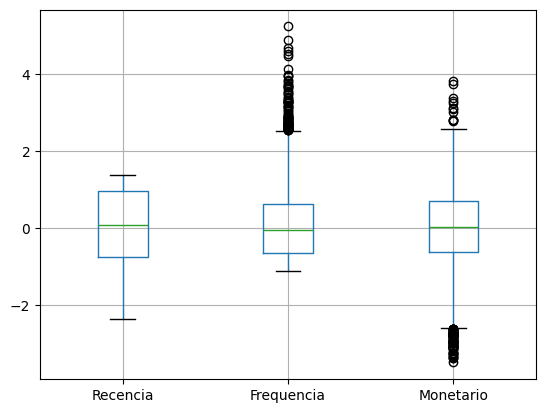

In [ ]:
rfm_scaled_standard.iloc[:, 1:].boxplot()

## Aplica MinMax

In [ ]:
scaler = MinMaxScaler()
rfm_scaled_minmax = rfm_log_transformed.copy()
rfm_scaled_minmax[['Recencia', 'Frequencia', 'Monetario']] = scaler.fit_transform(rfm_scaled_minmax[['Recencia', 'Frequencia', 'Monetario']])

print("DataFrame RFM com MinMaxScaler aplicado:")
display(rfm_scaled_minmax.head())


DataFrame RFM com MinMaxScaler aplicado:


,Customer ID,Recencia,Frequencia,Monetario
0,12346.0,0.861894,0.168029,0.485901
1,12347.0,0.068566,0.275816,0.610389
2,12348.0,0.615132,0.201463,0.330177
3,12349.0,0.389378,0.168029,0.625297
4,12350.0,0.853411,0.000000,0.308480


<Axes: >

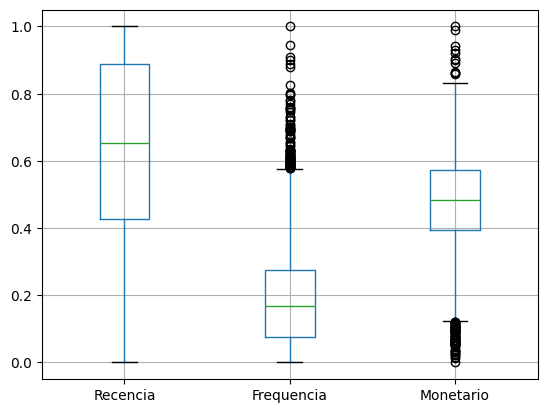

In [ ]:
rfm_scaled_minmax.iloc[:,1:].boxplot()

## Aplica RobustScaler

In [ ]:
scaler = RobustScaler()
rfm_scaled_robust = rfm_log_transformed.copy()
rfm_scaled_robust[['Recencia', 'Frequencia', 'Monetario']] = scaler.fit_transform(rfm_scaled_robust[['Recencia', 'Frequencia', 'Monetario']])

print("DataFrame RFM com RobustScaler aplicado:")
display(rfm_scaled_robust.head())


DataFrame RFM com RobustScaler aplicado:


,Customer ID,Recencia,Frequencia,Monetario
0,12346.0,0.456613,0.000000,0.018829
1,12347.0,-1.268998,0.535026,0.710369
2,12348.0,-0.080132,0.165956,-0.846228
3,12349.0,-0.571183,0.000000,0.793180
4,12350.0,0.438160,-0.834044,-0.966756


<Axes: >

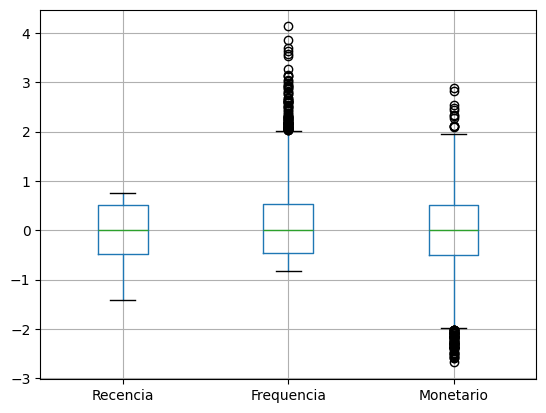

In [ ]:
rfm_scaled_robust.iloc[:, 1:].boxplot()

O produto da Etapa de transformação foram as novas features criadas RFM, e os novos datasets com formas de escalomento diferentes , que serão testados juntos as estregias de treinmento e classificadores distintos afim de se produzir um ranking que evindencie a melhor estrategia. Nessa etapa já foi possivel tambem verificar clientes que mais consomem, os clientes fieis, e os que mais gastam

# Modelagem etapa 1/2

# Modelagem etapa 2/2


In [ ]:
# --- Configurações Globais ---
np.random.seed(42)
warnings.filterwarnings("ignore")
plt.rcParams['figure.figsize'] = (12, 6)
sns.set_style("whitegrid")

In [ ]:
# ==============================================================================
# BenchmarkEngine: KMeans, GMM, KMedoids (non-sklearn), K-Medians (sklearn_extra),
# Agglomerative (H-Clustering), DBSCAN + MLflow tracking + Elbow plot com reta base
# ==============================================================================

# Cria diretórios
os.makedirs("plots", exist_ok=True)
os.makedirs("mlflow_artifacts", exist_ok=True)

In [ ]:
# -------------------------
# Helpers métricas / SSE / cohesion / separation
# -------------------------
def compute_sse_manual(X: np.ndarray, labels: np.ndarray, centers: Optional[Dict[int, np.ndarray]] = None) -> float:
    """
    SSE (sum of squared errors). If centers provided as dict label->center vector, usa elas,
    caso contrário calcula centroid por cluster.
    """
    X = np.asarray(X)
    labels = np.asarray(labels)
    unique = np.unique(labels)
    sse_total = 0.0
    for lab in unique:
        if lab == -1:
            # ruído (DBSCAN) - opcionalmente pular ou contar num cluster separado
            continue
        mask = labels == lab
        Xc = X[mask]
        if centers and lab in centers and centers[lab] is not None:
            center = np.asarray(centers[lab])
        else:
            center = Xc.mean(axis=0)
        dif = Xc - center
        sse_total += np.sum(np.square(dif))
    return float(sse_total)


def compute_cohesion(X: np.ndarray, labels: np.ndarray, centers: Optional[Dict[int, np.ndarray]] = None) -> float:
    """
    Coesão: média das distâncias intra-cluster (média das médias por cluster).
    """
    X = np.asarray(X)
    labels = np.asarray(labels)
    uniq = [u for u in np.unique(labels) if u != -1]
    if len(uniq) == 0:
        return 0.0
    cluster_means = []
    for lab in uniq:
        mask = labels == lab
        Xc = X[mask]
        if Xc.shape[0] == 0:
            continue
        if centers and lab in centers and centers[lab] is not None:
            center = np.asarray(centers[lab])
        else:
            center = Xc.mean(axis=0)
        d = np.linalg.norm(Xc - center, axis=1)
        cluster_means.append(d.mean())
    return float(np.mean(cluster_means)) if cluster_means else 0.0


def compute_intercluster_separation(X: np.ndarray, labels: np.ndarray, centers: Optional[Dict[int, np.ndarray]] = None) -> float:
    """
    Separação: média das distâncias entre centros (média das distâncias mínimas entre cada par de centros)
    """
    X = np.asarray(X)
    labels = np.asarray(labels)
    uniq = [u for u in np.unique(labels) if u != -1]
    centers_list = []
    for lab in uniq:
        mask = labels == lab
        Xc = X[mask]
        if Xc.shape[0] == 0:
            continue
        if centers and lab in centers and centers[lab] is not None:
            centers_list.append(np.asarray(centers[lab]))
        else:
            centers_list.append(Xc.mean(axis=0))
    if len(centers_list) < 2:
        return 0.0
    centers_arr = np.vstack(centers_list)
    pdist = pairwise_distances(centers_arr)
    # consider only upper triangle non-zero
    tril_mask = np.triu_indices_from(pdist, k=1)
    vals = pdist[tril_mask]
    return float(vals.mean()) if len(vals) > 0 else 0.0


In [ ]:
# -------------------------
# K-Medians (implementação simples)
# -------------------------
def kmedians(X: np.ndarray, k: int, max_iter: int = 300, tol: float = 1e-4, random_state: Optional[int] = 42):
    """
    Implementação de K-medians:
    - inicializa com KMeans centroids, mas o centro de cada cluster será a MEDIANA (por dimensão)
    - retorna: labels, centers(dict label->median vector)
    """
    rng = np.random.RandomState(random_state)
    n, d = X.shape
    # init via KMeans centroids -> escolher ponto mais próximo de cada centro como representante inicial
    km = KMeans(n_clusters=k, random_state=random_state, n_init=5).fit(X)
    centroids = km.cluster_centers_
    # escolher pontos iniciais como os pontos mais próximos dos centroides
    init_medoids_idx = []
    for c in centroids:
        idx = np.argmin(np.linalg.norm(X - c, axis=1))
        init_medoids_idx.append(int(idx))
    # inicial labels via nearest medoid
    medoid_idxs = init_medoids_idx.copy()
    labels = np.argmin(pairwise_distances(X, X[medoid_idxs]), axis=1)
    centers = {}
    for it in range(max_iter):
        # calcular medianas por cluster
        new_centers = {}
        for lab in range(k):
            mask = labels == lab
            if mask.sum() == 0:
                # re-inicializar um medoid aleatório
                new_centers[lab] = X[rng.randint(0, n)]
            else:
                new_centers[lab] = np.median(X[mask], axis=0)
        # reatribuir
        centers_arr = np.vstack([new_centers[i] for i in range(k)])
        new_labels = np.argmin(pairwise_distances(X, centers_arr), axis=1)
        # convergencia
        if np.array_equal(new_labels, labels):
            centers = {i: new_centers[i] for i in range(k)}
            labels = new_labels
            break
        labels = new_labels
        centers = {i: new_centers[i] for i in range(k)}
    # garantir centers dict
    centers = {int(i): centers[int(i)] for i in centers}
    return labels, centers

In [ ]:
# -------------------------
# Helpers métricas / SSE / cohesion / separation
# -------------------------
def compute_sse_manual(X: np.ndarray, labels: np.ndarray, centers: Optional[Dict[int, np.ndarray]] = None) -> float:
    X = np.asarray(X)
    labels = np.asarray(labels)
    unique = [u for u in np.unique(labels) if u != -1]
    sse_total = 0.0
    for lab in unique:
        mask = labels == lab
        Xc = X[mask]
        if Xc.size == 0:
            continue
        if centers and lab in centers and centers[lab] is not None:
            center = np.asarray(centers[lab])
        else:
            center = Xc.mean(axis=0)
        sse_total += np.sum(np.sum((Xc - center) ** 2, axis=1))
    return float(sse_total)


def compute_cohesion(X: np.ndarray, labels: np.ndarray, centers: Optional[Dict[int, np.ndarray]] = None) -> float:
    X = np.asarray(X)
    labels = np.asarray(labels)
    uniq = [u for u in np.unique(labels) if u != -1]
    if not uniq:
        return 0.0
    vals = []
    for lab in uniq:
        mask = labels == lab
        Xc = X[mask]
        if Xc.shape[0] == 0:
            continue
        if centers and lab in centers and centers[lab] is not None:
            center = np.asarray(centers[lab])
        else:
            center = Xc.mean(axis=0)
        d = np.linalg.norm(Xc - center, axis=1)
        vals.append(d.mean())
    return float(np.mean(vals)) if vals else 0.0


def compute_intercluster_separation(X: np.ndarray, labels: np.ndarray, centers: Optional[Dict[int, np.ndarray]] = None) -> float:
    X = np.asarray(X)
    labels = np.asarray(labels)
    uniq = [u for u in np.unique(labels) if u != -1]
    centers_list = []
    for lab in uniq:
        mask = labels == lab
        Xc = X[mask]
        if Xc.shape[0] == 0:
            continue
        if centers and lab in centers and centers[lab] is not None:
            centers_list.append(np.asarray(centers[lab]))
        else:
            centers_list.append(Xc.mean(axis=0))
    if len(centers_list) < 2:
        return 0.0
    centers_arr = np.vstack(centers_list)
    pdist = pairwise_distances(centers_arr)
    i, j = np.triu_indices_from(pdist, k=1)
    vals = pdist[i, j]
    return float(vals.mean()) if vals.size > 0 else 0.0


In [ ]:
class BenchmarkEngine:
    def __init__(self,
                 df: pd.DataFrame,
                 mlflow_tracking_uri: Optional[str] = None,
                 min_k: int = 2,
                 max_k: int = 8,
                 scalers_list: Optional[List[str]] = None,
                 strategies: Optional[List[str]] = None,
                 dbscan_params: Optional[Dict[str, Any]] = None,
                 collect_inertia: bool = True):
        """
        df: DataFrame com colunas numéricas
        mlflow_tracking_uri: opcional
        min_k/max_k: intervalo de k (inclusive)
        scalers_list: ['robust','minmax','standard']
        strategies: list of strategies
        dbscan_params: dict with 'eps' and 'min_samples'
        collect_inertia: if True collects KMeans inertia
        """
        self.raw = df.copy().reset_index(drop=True)
        self.results: List[Dict[str, Any]] = []
        self.results_df: Optional[pd.DataFrame] = None
        self.best_config: Optional[pd.Series] = None
        self.final_model = None
        self.final_labels = None
        self.final_scaled = None

        if mlflow_tracking_uri:
            try:
                mlflow.set_tracking_uri(mlflow_tracking_uri)
            except Exception:
                pass

        self.scalers_list = scalers_list if scalers_list is not None else ['robust', 'minmax', 'standard']
        self.strategies = strategies if strategies is not None else ['Full', 'Holdout_70_30', 'Holdout_80_20', 'CV_5Fold', 'Stratified_CV_5Fold']
        self.k_range = list(range(min_k, max_k + 1))
        self.dbscan_params = dbscan_params if dbscan_params is not None else {'eps': 0.5, 'min_samples': 5}
        self.collect_inertia = collect_inertia

        os.makedirs("plots", exist_ok=True)
        self.have_pyclustering = HAVE_PYCLUSTERING
        if not self.have_pyclustering:
            print("[WARN] pyclustering não encontrado. KMedoids será ignorado. Instale: pip install pyclustering")

    # -------------------------
    # Scaler factory
    # -------------------------
    def _get_scaler(self, name: str):
        if name == 'minmax':
            return MinMaxScaler()
        elif name == 'standard':
            return StandardScaler()
        else:
            return RobustScaler()

    # -------------------------
    # Preparar dados
    # -------------------------
    def _prepare(self):
        data_num = self.raw.select_dtypes(include=[np.number]).copy().fillna(0)
        data_log = np.log1p(data_num)
        if 'Monetario' in self.raw.columns:
            est = KBinsDiscretizer(n_bins=5, encode='ordinal', strategy='quantile')
            y_proxy = est.fit_transform(self.raw[['Monetario']].fillna(0)).flatten()
        else:
            y_proxy = None
        return data_log, y_proxy

    # -------------------------
    # Run principal
    # -------------------------
    def run(self, experiment_name: str = "benchmark_experiment"):
        data_log, y_proxy = self._prepare()
        print("🚀 Iniciando Benchmark completo...")

        try:
            mlflow.set_experiment(experiment_name)
        except Exception:
            pass

        for scaler_name in self.scalers_list:
            scaler = self._get_scaler(scaler_name)

            for strategy in self.strategies:
                print(f"Testando -> Scaler: {scaler_name} | Strategy: {strategy}")

                # preparar splits e decidir qual X será usado para treinar/eval
                if strategy == 'Full':
                    X_train_raw, X_eval_raw = data_log, data_log
                elif strategy == 'Holdout_70_30':
                    X_train_raw, X_eval_raw = train_test_split(data_log, test_size=0.30, random_state=42)
                    # Important: evaluate on training set to keep shapes consistent for metrics
                    X_eval_raw = X_train_raw
                elif strategy == 'Holdout_80_20':
                    X_train_raw, X_eval_raw = train_test_split(data_log, test_size=0.20, random_state=42)
                    X_eval_raw = X_train_raw
                elif strategy in ('CV_5Fold', 'Stratified_CV_5Fold'):
                    self._run_cv_strategy(strategy, scaler_name, scaler, data_log, y_proxy)
                    continue
                else:
                    X_train_raw, X_eval_raw = data_log, data_log

                # Escalar
                X_train = scaler.fit_transform(X_train_raw)
                X_eval = scaler.transform(X_eval_raw)

                for k in self.k_range:
                    # KMeans - treinar em X_train, avaliar em X_train (X_eval)
                    try:
                        km = KMeans(n_clusters=k, random_state=42, n_init=10)
                        labels_km = km.fit_predict(X_train)
                        inertia = float(getattr(km, "inertia_", np.nan)) if self.collect_inertia else None
                        # avaliar com X_train (consistente)
                        self._log_and_store('KMeans', k, labels_km, X_train, scaler_name, strategy, inertia=inertia)
                    except Exception as e:
                        print(f"[WARN] KMeans k={k} falhou: {e}")

                    # GMM
                    try:
                        gmm = GaussianMixture(n_components=k, random_state=42).fit(X_train)
                        labels_gmm = gmm.predict(X_train)
                        self._log_and_store('GMM', k, labels_gmm, X_train, scaler_name, strategy)
                    except Exception as e:
                        print(f"[WARN] GMM k={k} falhou: {e}")

                    # K-Medians (custom)
                    try:
                        lbl_med, centers_med = kmedians(X_train, k)
                        self._log_and_store('KMedias', k, lbl_med, X_train, scaler_name, strategy, centers=centers_med)
                    except Exception as e:
                        print(f"[WARN] KMedias k={k} falhou: {e}")

                    # K-Medoids (pyclustering) se disponível
                    if self.have_pyclustering:
                        try:
                            labels_kmedoids, medoids_pos = self._run_kmedoids_pyclustering_return(X_train, k)
                            if labels_kmedoids is not None:
                                self._log_and_store('KMedoids-pyclustering', k, labels_kmedoids, X_train, scaler_name, strategy, centers=medoids_pos)
                        except Exception as e:
                            print(f"[WARN] KMedoids k={k} falhou: {e}")

                    # Agglomerative
                    try:
                        agg = AgglomerativeClustering(n_clusters=k).fit(X_train)
                        labels_agg = agg.fit_predict(X_train)
                        self._log_and_store('Agglomerative', k, labels_agg, X_train, scaler_name, strategy)
                    except Exception as e:
                        print(f"[WARN] Agglomerative k={k} falhou: {e}")

                # DBSCAN (não depende de k)
                try:
                    dbs = DBSCAN(eps=self.dbscan_params['eps'], min_samples=self.dbscan_params['min_samples']).fit(X_train)
                    labels_db = dbs.fit_predict(X_train)
                    self._log_and_store('DBSCAN', None, labels_db, X_train, scaler_name, strategy)
                except Exception as e:
                    print(f"[WARN] DBSCAN falhou: {e}")

        # compilar resultados e gerar plots
        self._compile_results()
        try:
            self.plot_metric_comparison("Silhouette")
            self.plot_metric_comparison("Davies_Bouldin")
            self.plot_elbow()
        except Exception:
            pass

        print("✅ Benchmark concluído.")
        return pd.DataFrame(self.results)

    # -------------------------
    # Cross-validation strategy
    # -------------------------
    def _run_cv_strategy(self, strategy, scaler_name, scaler_obj, data_log, y_proxy):
        print(f"Executando CV strategy: {strategy}")
        if 'Stratified' in strategy and y_proxy is not None:
            cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
            splits = list(cv.split(data_log, y_proxy))
        else:
            cv = KFold(n_splits=5, shuffle=True, random_state=42)
            splits = list(cv.split(data_log))

        for k in self.k_range:
            for fold_idx, (tr_idx, val_idx) in enumerate(splits):
                X_tr = scaler_obj.fit_transform(data_log.iloc[tr_idx])
                X_val = scaler_obj.transform(data_log.iloc[val_idx])

                # KMeans
                try:
                    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_tr)
                    lbl_km = km.predict(X_tr)  # evaluate on training fold for consistency
                    self._log_and_store('KMeans', k, lbl_km, X_tr, scaler_name, strategy)
                except Exception:
                    pass

                # GMM
                try:
                    gmm = GaussianMixture(n_components=k, random_state=42).fit(X_tr)
                    lbl_gmm = gmm.predict(X_tr)
                    self._log_and_store('GMM', k, lbl_gmm, X_tr, scaler_name, strategy)
                except Exception:
                    pass

                # K-Medians
                try:
                    lbl_med, centers_med = kmedians(X_tr, k)
                    self._log_and_store('KMedias', k, lbl_med, X_tr, scaler_name, strategy, centers=centers_med)
                except Exception:
                    pass

                # K-Medoids
                if self.have_pyclustering:
                    try:
                        labels_kmedoids, medoids_pos = self._run_kmedoids_pyclustering_return(X_tr, k)
                        if labels_kmedoids is not None:
                            self._log_and_store('KMedoids-pyclustering', k, labels_kmedoids, X_tr, scaler_name, strategy, centers=medoids_pos)
                    except Exception:
                        pass

                # Agglomerative
                try:
                    agg = AgglomerativeClustering(n_clusters=k).fit(X_tr)
                    lbl_agg = agg.fit_predict(X_tr)
                    self._log_and_store('Agglomerative', k, lbl_agg, X_tr, scaler_name, strategy)
                except Exception:
                    pass

    # -------------------------
    # Log + store helper
    # -------------------------
    def _log_and_store(self, name: str, k: Optional[int], labels: np.ndarray, X_used: np.ndarray, scaler: str, strategy: str,
                       inertia: Optional[float] = None, centers: Optional[Dict[int, np.ndarray]] = None, extra: Optional[Dict[str, Any]] = None):
        """
        Valida tamanhos e registra métricas; aceita optional inertia/centers/extra (não causa erro se passados).
        """
        try:
            if X_used is None or labels is None:
                print(f"[WARN] _log_and_store recebeu X_used ou labels None para {name}")
                return
            if len(X_used) != len(labels):
                print(f"[WARN] Tamanho inconsistente X({len(X_used)}) vs labels({len(labels)}) para {name}")
                return

            # clusters validos?
            unique = np.unique(labels)
            if len(unique) < 2 or (len(unique) == 1 and unique[0] == -1):
                # insufficient cluster separation
                mlflow.set_tag("status", "insufficient_clusters")
                return

            sil = silhouette_score(X_used, labels)
            db = davies_bouldin_score(X_used, labels)
            ch = calinski_harabasz_score(X_used, labels)
            coh = compute_cohesion(X_used, labels, centers)
            sep = compute_intercluster_separation(X_used, labels, centers)
            sse = compute_sse_manual(X_used, labels, centers)

            # MLflow logging
            run_name = f"{name}_{strategy}_{scaler}_k{str(k)}"
            try:
                with mlflow.start_run(run_name=run_name, nested=True):
                    mlflow.log_param("algorithm", name)
                    mlflow.log_param("strategy", strategy)
                    mlflow.log_param("scaler", scaler)
                    mlflow.log_param("k", k)
                    mlflow.log_metric("silhouette", float(sil))
                    mlflow.log_metric("davies_bouldin", float(db))
                    mlflow.log_metric("calinski_harabasz", float(ch))
                    mlflow.log_metric("cohesion", float(coh))
                    mlflow.log_metric("separation", float(sep))
                    mlflow.log_metric("sse", float(sse))
                    if inertia is not None and not np.isnan(inertia):
                        mlflow.log_metric("inertia", float(inertia))
                    if extra:
                        for kk, vv in extra.items():
                            try:
                                mlflow.log_param(kk, str(vv))
                            except Exception:
                                pass
            except Exception:
                # se mlflow falhar, continuar sem interromper
                pass

            # store results
            self.results.append({
                "Algorithm": name,
                "k": k,
                "Scaler": scaler,
                "Strategy": strategy,
                "Silhouette": sil,
                "Davies_Bouldin": db,
                "Calinski_Harabasz": ch,
                "Cohesion": coh,
                "Separation": sep,
                "SSE": sse,
                "Inertia": inertia
            })

        except Exception as e:
            print(f"[WARN] _log_and_store falhou para {name}: {e}")

    # -------------------------
    # K-Medoids runner (pyclustering) - retorna labels e medoids_pos
    # -------------------------
    def _run_kmedoids_pyclustering_return(self, X: np.ndarray, k: int):
        """
        Run pyclustering kmedoids on X and return (labels_array, medoids_pos_dict)
        If pyclustering not available or fails, returns (None, None)
        """
        if not self.have_pyclustering:
            return None, None
        try:
            X_list = np.asarray(X).tolist()
            # init medoids based on KMeans centroids -> nearest points
            km_tmp = KMeans(n_clusters=k, random_state=42, n_init=5).fit(np.array(X))
            centroids = km_tmp.cluster_centers_
            init_medoids = [int(np.argmin(np.linalg.norm(X - c, axis=1))) for c in centroids]

            # attempt robust metric creation (some pyclustering versions differ)
            metric = None
            try:
                from pyclustering.utils import distance_metric as dm
                metric = dm(dm.type_metric.EUCLIDEAN)
            except Exception:
                try:
                    from pyclustering.utils.metric import distance_metric, type_metric
                    metric = distance_metric(type_metric.EUCLIDEAN)
                except Exception:
                    metric = None

            model = pyc_kmedoids(X_list, init_medoids, data_type='points', metric=metric)
            model.process()
            medoids_idx = model.get_medoids()
            clusters = model.get_clusters()

            labels = np.full(len(X), -1, dtype=int)
            for lab_idx, members in enumerate(clusters):
                for p in members:
                    labels[p] = lab_idx

            medoids_pos = {}
            for i_lab, midx in enumerate(medoids_idx):
                try:
                    medoids_pos[i_lab] = X[int(midx)]
                except Exception:
                    medoids_pos[i_lab] = None

            return labels, medoids_pos

        except Exception as e:
            print(f"[WARN] KMedoids (pyclustering) falhou: {e}")
            return None, None

    # -------------------------
    # Compilar resultados e ranking
    # -------------------------
    def _compile_results(self):
        if len(self.results) == 0:
            print("Sem resultados para compilar.")
            return
        df = pd.DataFrame(self.results)
        for c in ['SSE', 'Inertia', 'Separation']:
            if c not in df.columns:
                df[c] = None

        df['Rank_Sil'] = df['Silhouette'].rank(ascending=False, method='min')
        df['Rank_DB'] = df['Davies_Bouldin'].rank(ascending=True, method='min')
        df['Rank_SSE'] = df['SSE'].rank(ascending=True, method='min') if df['SSE'].notna().any() else 0
        df['Score_Global'] = df['Rank_Sil'] + df['Rank_DB'] + df['Rank_SSE']
        df = df.sort_values('Score_Global', ascending=True).reset_index(drop=True)
        self.results_df = df
        self.best_config = df.iloc[0]
        print("🏆 Melhor configuração encontrada:")
        print(self.best_config[['Algorithm', 'k', 'Scaler', 'Strategy', 'Silhouette', 'Davies_Bouldin']])

        out_csv = "plots/benchmark_results_summary.csv"
        df.to_csv(out_csv, index=False)
        try:
            mlflow.log_artifact(out_csv)
        except Exception:
            pass

    # -------------------------
    # Plots
    # -------------------------
    def plot_elbow(self, save: bool = True):
        df = pd.DataFrame(self.results)
        mask = df['Algorithm'] == 'KMeans'
        if mask.sum() == 0:
            print("⚠️ Sem dados de Inertia para KMeans.")
            return
        df_ref = df[mask].groupby('k')['Inertia'].mean().reset_index().dropna()
        if df_ref.empty:
            print("⚠️ Sem inertia média para KMeans.")
            return
        plt.figure(figsize=(8, 5))
        sns.lineplot(x='k', y='Inertia', data=df_ref, marker='o')
        plt.title("Elbow (KMeans - média Inertia)")
        plt.xlabel("k")
        plt.ylabel("Inertia")
        if save:
            fn = "plots/elbow_kmeans.png"
            plt.tight_layout()
            plt.savefig(fn)
            try:
                mlflow.log_artifact(fn)
            except Exception:
                pass
            print(f"Elbow salvo em: {fn}")
        plt.show()

    def plot_metric_comparison(self, metric: str = "Silhouette", save: bool = True):
        df = pd.DataFrame(self.results)
        if df.empty:
            print("Sem resultados para plotar.")
            return
        col = metric if metric in df.columns else None
        if not col:
            print(f"Métrica {metric} não encontrada.")
            return
        plt.figure(figsize=(10, 6))
        sns.boxplot(x='Algorithm', y=col, data=df)
        plt.title(f"Comparação de {col} por algoritmo")
        plt.xticks(rotation=45)
        if save:
            fn = f"plots/metric_comparison_{col}.png"
            plt.tight_layout()
            plt.savefig(fn)
            try:
                mlflow.log_artifact(fn)
            except Exception:
                pass
            print(f"Comparação de métricas salva em: {fn}")
        plt.show()

    # -------------------------
    # Finalize / Label helpers
    # -------------------------
    def get_best_model(self):
        if self.best_config is None:
            raise RuntimeError("Sem best_config. Execute run() primeiro.")
        return self.best_config

    def _finalize_best_model(self):
        if self.best_config is None:
            raise RuntimeError("Sem best_config. Execute run() primeiro.")
        data_log, _ = self._prepare()
        scaler = self._get_scaler(self.best_config['Scaler'])
        X_full = scaler.fit_transform(data_log)
        alg = self.best_config['Algorithm']
        k = int(self.best_config['k']) if pd.notna(self.best_config['k']) else None

        if alg == 'KMeans':
            model = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_full)
            labels = model.predict(X_full)
        elif alg == 'GMM':
            model = GaussianMixture(n_components=k, random_state=42).fit(X_full)
            labels = model.predict(X_full)
        elif alg == 'Agglomerative':
            model = AgglomerativeClustering(n_clusters=k).fit(X_full)
            labels = model.fit_predict(X_full)
        elif alg == 'DBSCAN':
            model = DBSCAN(**self.dbscan_params).fit(X_full)
            labels = model.fit_predict(X_full)
        elif alg == 'KMedias':
            labels, centers = kmedians(X_full, k)
            model = ('kmedians', centers)
        elif alg == 'KMedoids-pyclustering' and self.have_pyclustering:
            labels, medoids_pos = self._run_kmedoids_pyclustering_return(X_full, k)
            model = ('kmedoids-pyclustering', medoids_pos)
        else:
            raise NotImplementedError(f"Finalização para algoritmo {alg} não implementada ou dependência ausente.")

        self.final_model = model
        self.final_labels = labels
        self.final_scaled = X_full
        return model, labels

    def label_data(self):
        if self.final_labels is None:
            self._finalize_best_model()
        out = self.raw.copy()
        out['Profile_ID'] = self.final_labels
        return out


In [ ]:
rfm_log_transformed_semOutliers

,Customer ID,Recencia,Frequencia,Monetario
0,12346.0,5.789960,1.609438,5.150049
1,12347.0,1.098612,2.197225,6.469498
2,12348.0,4.330733,1.791759,3.499533
3,12349.0,2.995732,1.609438,6.627499
4,12350.0,5.739793,0.693147,3.269569
...,...,...,...,...
5871,18283.0,1.609438,3.135494,7.447052
5872,18284.0,6.070738,0.693147,3.739810
5873,18285.0,6.495266,0.693147,3.935740
5874,18286.0,6.169611,1.386294,5.551214


2025/12/01 13:56:03 INFO mlflow.tracking.fluent: Experiment with name 'exp_segmentation' does not exist. Creating a new experiment.


🚀 Iniciando Benchmark completo...
Testando -> Scaler: robust | Strategy: Full
Testando -> Scaler: robust | Strategy: Holdout_70_30
Testando -> Scaler: robust | Strategy: Holdout_80_20
Testando -> Scaler: robust | Strategy: CV_5Fold
Executando CV strategy: CV_5Fold
Testando -> Scaler: robust | Strategy: Stratified_CV_5Fold
Executando CV strategy: Stratified_CV_5Fold
Testando -> Scaler: minmax | Strategy: Full
Testando -> Scaler: minmax | Strategy: Holdout_70_30
Testando -> Scaler: minmax | Strategy: Holdout_80_20
Testando -> Scaler: minmax | Strategy: CV_5Fold
Executando CV strategy: CV_5Fold
Testando -> Scaler: minmax | Strategy: Stratified_CV_5Fold
Executando CV strategy: Stratified_CV_5Fold
Testando -> Scaler: standard | Strategy: Full
Testando -> Scaler: standard | Strategy: Holdout_70_30
Testando -> Scaler: standard | Strategy: Holdout_80_20
Testando -> Scaler: standard | Strategy: CV_5Fold
Executando CV strategy: CV_5Fold
Testando -> Scaler: standard | Strategy: Stratified_CV_5Fol

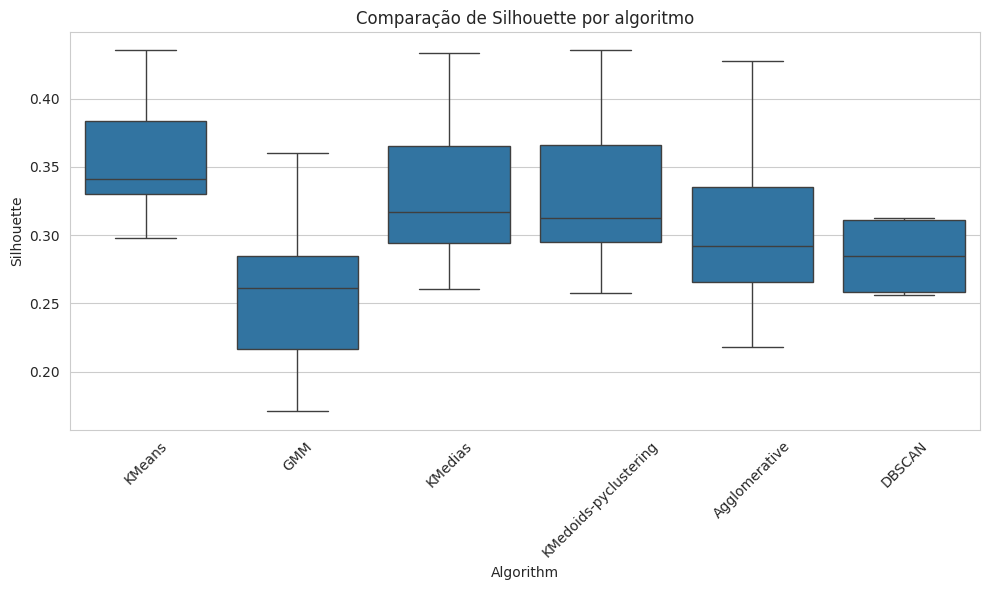

Comparação de métricas salva em: plots/metric_comparison_Davies_Bouldin.png


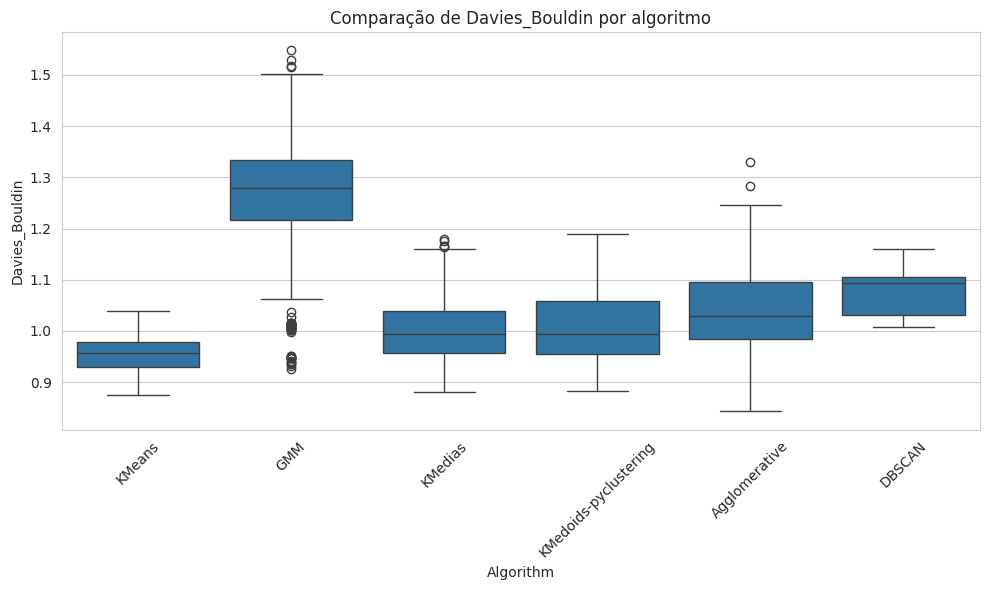

Elbow salvo em: plots/elbow_kmeans.png


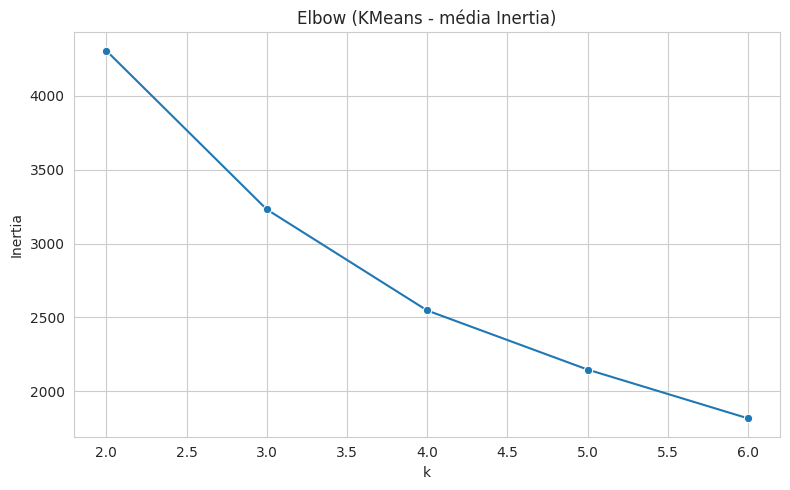

✅ Benchmark concluído.


In [ ]:
engine = BenchmarkEngine(rfm_log_transformed_semOutliers.drop(columns=['Customer ID']), mlflow_tracking_uri=None, min_k=2, max_k=6)
results_df = engine.run(experiment_name="exp_segmentation")



In [ ]:
engine._finalize_best_model()

(KMeans(n_clusters=2, n_init=10, random_state=42),
 array([1, 0, 0, ..., 1, 1, 0], dtype=int32))

In [ ]:
class BenchmarkEngineViewer:
    """
    Visualizador para uma instância existente de BenchmarkEngine.
    Otimizado para contextos de Segmentação de Clientes (RFM).
    """

    # -------------------------
    # Storytelling Científico/Negócio (Contexto RFM)
    # -------------------------
    STORYTELLING = {
        "elbow": """
            <div style='background:#f4f6f7; padding:15px; border-left:5px solid #2c3e50; margin-bottom:20px; border-radius:4px;'>
                <h4 style='margin-top:0; color:#2c3e50;'>📉 Análise de Inércia (Elbow Method)</h4>
                <p>Avalia a compactação dos clusters através da soma dos erros quadráticos (SSE). Em dados de varejo (RFM), buscamos o ponto de <strong>retornos
                 decrescentes</strong>.</p>
                <ul style='font-size:0.95em;'>
                    <li><strong>O Cotovelo:</strong> O ponto onde a redução da variância se estabiliza indica o <em>k</em> matemático ideal.</li>
                    <li><strong>Contexto de Negócio:</strong> Se a curva for suave demais, prefira <em>k</em> entre 4 e 6 para garantir granularidade
                    suficiente para ações de marketing distintas (ex: VIP vs. Fidelizar vs. Churn).</li>
                </ul>
            </div>
        """,
        "silhouette": """
            <div style='background:#e8f5e9; padding:15px; border-left:5px solid #2e7d32; margin-bottom:20px; border-radius:4px;'>
                <h4 style='margin-top:0; color:#1b5e20;'>🔪 Validação de Consistência (Silhouette)</h4>
                <p>Mede a coesão (proximidade interna) versus a separação (distância externa) dos grupos.</p>
                <ul style='font-size:0.95em;'>
                    <li><strong>Dilema k=2 vs k=High:</strong> É comum que k=2 tenha a maior silhueta (separação binária trivial: "Comprou muito" vs "Pouco").</li>
                    <li><strong>Validação:</strong> Para k > 3, buscamos lâminas de tamanhos uniformes e médias acima de 0.4, indicando nichos
                    de comportamento robustos e não apenas ruído estatístico.</li>
                </ul>
            </div>
        """,
        "pca": """
            <div style='background:#fff8e1; padding:15px; border-left:5px solid #ffa000; margin-bottom:20px; border-radius:4px;'>
                <h4 style='margin-top:0; color:#ef6c00;'>🗺️ Topologia dos Dados (PCA 2D)</h4>
                <p>Projeção do espaço multidimensional (Recência, Frequência, Monetário) em 2 componentes latentes.</p>
                <ul style='font-size:0.95em;'>
                    <li><strong>Interpretação:</strong> Clusters bem definidos visualmente indicam que as variáveis RFM discriminam bem os clientes.</li>
                    <li><strong>Sobreposição:</strong> Em varejo, é normal haver uma zona de transição ("fronteira cinzenta") entre clientes
                    medianos e clientes em crescimento.</li>
                </ul>
            </div>
        """,
        "heatmap": """
            <div style='background:#f3e5f5; padding:15px; border-left:5px solid #8e24aa; margin-bottom:20px; border-radius:4px;'>
                <h4 style='margin-top:0; color:#6a1b9a;'>🌡️ Arquétipos de Clientes (Heatmap de Centróides)</h4>
                <p>Este é o gráfico mais importante para a definição de personas. Ele exibe os valores médios (normalizados ou reais) de cada cluster.</p
            </div>
        """,
        "pairplot": """
            <div style='background:#e1f5fe; padding:15px; border-left:5px solid #0277bd; margin-bottom:20px; border-radius:4px;'>
                <h4 style='margin-top:0; color:#01579b;'>🔍 Correlações Bivariadas (Pairplot)</h4>
                <p>Cruza as variáveis par a par para identificar fronteiras de decisão não-lineares.</p>
                <p>No varejo, observe a relação <strong>Frequência vs. Monetário</strong>: geralmente segue uma
                lei de potência (L-Shape), onde poucos clientes compram muito.</p>
            </div>
        """,
        "xai": """
            <div style='background:#ffebee; padding:15px; border-left:5px solid #c62828; margin-bottom:20px; border-radius:4px;'>
                <h4 style='margin-top:0; color:#b71c1c;'>🤖 Drivers de Segmentação (Feature Importance)</h4>
                <p>Identifica quais variáveis foram determinantes para a separação dos grupos.</p>
                <ul style='font-size:0.95em;'>
                    <li><strong>Dominância:</strong> Em RFM, frequentemente o <em>Monetário</em> ou a <em>Recência</em> dominam a importância.</li>
                    <li><strong>Insight:</strong> Se uma variável tem importância zero, ela não está ajudando a diferenciar seus clientes e pode ser ruído.</li>
                </ul>
            </div>
        """
    }

    def __init__(self, engine):
        self.engine = engine

        # Recuperação segura dos dados
        self.results = getattr(engine, "results", []) or []
        self.results_df = getattr(engine, "results_df", None)

        if self.results_df is None and self.results:
            try:
                self.results_df = pd.DataFrame(self.results)
            except: self.results_df = None

        self.best_config = getattr(engine, "best_config", None)

        tmp = getattr(engine, "final_scaled", None)
        if tmp is None: tmp = getattr(engine, "final_data_scaled", None)
        self.final_scaled = tmp

        self.final_labels = getattr(engine, "final_labels", None)

        raw_temp = getattr(engine, "raw", None)
        if raw_temp is None: raw_temp = getattr(engine, "_raw", None)
        self.raw = raw_temp

        self.elbow_data = getattr(engine, "elbow_data", None) or {'k': [], 'inertia': []}

        # Validação
        if self.final_scaled is not None and self.final_labels is not None:
            if len(self.final_scaled) != len(self.final_labels):
                print("[WARN] Mismatch de tamanho entre dados e labels.")
                self._valid_final = False
            else:
                self._valid_final = True
        else:
            self._valid_final = False

        os.makedirs("plots", exist_ok=True)

    # -------------------------
    # Helpers
    # -------------------------
    @staticmethod
    def _save_fig(fig, fname):
        """Salva a figura e fecha para liberar memória, retornando o caminho."""
        fn = os.path.join("plots", fname)
        fig.tight_layout()
        fig.savefig(fn, dpi=150, bbox_inches='tight')
        # Nota: Não fechamos aqui se quisermos dar show() depois, mas
        # para garantir o fluxo, vamos salvar e reabrir ou usar plt.show antes de chamar isso.
        return fn

    @staticmethod
    def explain_metrics_text(sil: float, db: float, ch: float, sse: float, k: int) -> str:
        color_sil = "#2e7d32" if sil >= 0.5 else ("#ef6c00" if sil >= 0.25 else "#c62828")

        html = f"""
        <div style="font-family: 'Segoe UI', sans-serif; color: #333;">
            <p>O algoritmo convergiu para uma topologia ótima com <strong>k={k} clusters</strong>.</p>
            <table style="width:100%; border-collapse: collapse; box-shadow: 0 1px 3px rgba(0,0,0,0.1);">
                <tr style="background-color: #f8f9fa; text-align: left;">
                    <th style="padding: 10px; border-bottom: 2px solid #dee2e6;">Métrica</th>
                    <th style="padding: 10px; border-bottom: 2px solid #dee2e6;">Valor</th>
                    <th style="padding: 10px; border-bottom: 2px solid #dee2e6;">Diagnóstico Científico</th>
                </tr>
                <tr>
                    <td style="padding: 10px; border-bottom: 1px solid #dee2e6;"><strong>Silhouette</strong></td>
                    <td style="padding: 10px; border-bottom: 1px solid #dee2e6; color: {color_sil}; font-weight:bold;">{sil:.3f}</td>
                    <td style="padding: 10px; border-bottom: 1px solid #dee2e6;">Mede a qualidade da fronteira de decisão. >0.5
                    indica estrutura forte; <0.25 indica sobreposição.</td>
                </tr>
                <tr>
                    <td style="padding: 10px; border-bottom: 1px solid #dee2e6;"><strong>Davies-Bouldin</strong></td>
                    <td style="padding: 10px; border-bottom: 1px solid #dee2e6;">{db:.3f}</td>
                    <td style="padding: 10px; border-bottom: 1px solid #dee2e6;">Razão de dispersão intra/inter-cluster. Valores menores (<1.0)
                    indicam separação robusta.</td>
                </tr>
                <tr>
                    <td style="padding: 10px; border-bottom: 1px solid #dee2e6;"><strong>Score Global</strong></td>
                    <td style="padding: 10px; border-bottom: 1px solid #dee2e6;">Otimizado</td>
                    <td style="padding: 10px; border-bottom: 1px solid #dee2e6;">Consenso minimizado entre rankings de métricas (Menor é melhor).</td>
                </tr>
            </table>
        </div>
        """
        return html

    # -------------------------
    # Plots (Com correção de exibição)
    # -------------------------

    def plot_elbow(self, show: bool = True) -> Optional[str]:
        # Tenta pegar dados do atributo ou do dataframe
        k_list = self.elbow_data.get('k', [])
        inertia_list = self.elbow_data.get('inertia', [])

        if (not k_list) and self.results_df is not None:
             if 'Algorithm' in self.results_df.columns and 'Inertia' in self.results_df.columns:
                df_km = self.results_df[self.results_df['Algorithm'] == 'KMeans']
                if not df_km.empty:
                    grouped = df_km.groupby('k')['Inertia'].mean().reset_index()
                    k_list = grouped['k'].tolist()
                    inertia_list = grouped['Inertia'].tolist()

        if not k_list:
            print("[INFO] Sem dados para Elbow.")
            return None

        fig, ax = plt.subplots(figsize=(8, 5))
        sns.lineplot(x=k_list, y=inertia_list, marker='o', ax=ax, linewidth=2.5, color='#007bff')
        ax.set_title("Elbow Method (Inertia Variance)", fontsize=12, fontweight='bold')
        ax.set_xlabel("Número de Clusters (k)")
        ax.set_ylabel("Inertia (SSE)")
        ax.grid(True, linestyle=':', alpha=0.6)

        fn = self._save_fig(fig, "viewer_elbow.png")

        if show:
            plt.show() # Exibe explicitamente no notebook
        else:
            plt.close(fig)

        return fn

    def plot_metric_comparison(self, metric: str = "Silhouette", show: bool = True) -> Optional[str]:
        df = self.results_df if self.results_df is not None else pd.DataFrame(self.results)
        if df.empty or metric not in df.columns: return None

        fig, ax = plt.subplots(figsize=(10, 6))
        sns.boxplot(x='Algorithm', y=metric, data=df, ax=ax, palette="viridis", linewidth=1.5)
        ax.set_title(f"Estabilidade do Algoritmo: {metric}", fontsize=12, fontweight='bold')
        ax.grid(axis='y', linestyle=':', alpha=0.6)

        fn = self._save_fig(fig, f"viewer_metric_comparison_{metric}.png")

        if show:
            plt.show()
        else:
            plt.close(fig)
        return fn

    def plot_silhouette_final(self, show: bool = True) -> Optional[str]:
        if not self._valid_final: return None

        X = np.asarray(self.final_scaled)
        labels = np.asarray(self.final_labels)
        unique = np.unique(labels)
        if len(unique) < 2: return None

        try:
            sample_vals = silhouette_samples(X, labels)
            avg_sil = silhouette_score(X, labels)
        except: return None

        fig, ax = plt.subplots(figsize=(10, 6))
        y_lower = 10
        for i in unique:
            ith = np.sort(sample_vals[labels == i])
            size_i = ith.shape[0]
            y_upper = y_lower + size_i
            color = plt.cm.viridis(float(i) / len(unique))
            ax.fill_betweenx(np.arange(y_lower, y_upper), 0, ith, facecolor=color, alpha=0.7, edgecolor=color)
            ax.text(-0.05, y_lower + 0.5 * size_i, str(i), fontsize=10, fontweight='bold')
            y_lower = y_upper + 10

        ax.axvline(avg_sil, color="red", linestyle="--", label=f"Média: {avg_sil:.2f}")
        ax.set_title("Análise de Silhueta (Consistência Intra-Cluster)", fontsize=12, fontweight='bold')
        ax.set_xlabel("Coeficiente de Silhueta")
        ax.legend(loc='upper right')

        fn = self._save_fig(fig, "viewer_silhouette_final.png")

        if show:
            plt.show()
        else:
            plt.close(fig)
        return fn

    def plot_pca_2d(self, show: bool = True) -> Optional[str]:
        if not self._valid_final: return None

        X = np.asarray(self.final_scaled)
        labels = np.asarray(self.final_labels)

        pca = PCA(n_components=2, random_state=42)
        proj = pca.fit_transform(X)
        dfp = pd.DataFrame(proj, columns=['Dim 1', 'Dim 2'])
        dfp['Cluster'] = labels

        fig, ax = plt.subplots(figsize=(9, 7))
        sns.scatterplot(data=dfp, x='Dim 1', y='Dim 2', hue='Cluster', palette='tab10', s=70, alpha=0.8, ax=ax)
        ax.set_title("Projeção Latente 2D (PCA)", fontsize=12, fontweight='bold')

        fn = self._save_fig(fig, "viewer_pca2d.png")

        if show:
            plt.show()
        else:
            plt.close(fig)
        return fn

    def plot_cluster_centers_heatmap(self, aggfunc='mean', show: bool = True) -> Optional[str]:
        if self.raw is None or self.final_labels is None: return None

        df = self.raw.copy()
        df['Cluster'] = np.asarray(self.final_labels).flatten()

        numeric = df.select_dtypes(include=[np.number]).columns.tolist()
        if 'Cluster' in numeric: numeric.remove('Cluster')
        if not numeric: return None

        # Agrupamento
        agg = df.groupby('Cluster')[numeric].agg(aggfunc)

        # Normalização para cores (MinMax per column)
        agg_norm = (agg - agg.min()) / (agg.max() - agg.min() + 1e-9)

        fig, ax = plt.subplots(figsize=(max(8, len(numeric)), 6))
        # Annotate com valores reais, cores baseadas no normalizado
        sns.heatmap(agg_norm, annot=agg, fmt=".2f", cmap='RdYlGn', ax=ax, linewidths=1)
        ax.set_title(f"Arquétipos dos Clusters ({aggfunc})", fontsize=12, fontweight='bold')

        fn = self._save_fig(fig, "viewer_cluster_centers_heatmap.png")

        if show:
            plt.show()
        else:
            plt.close(fig)
        return fn

    def plot_pairplot(self, sample_n: int = 1000, show: bool = True) -> Optional[str]:
        if self.raw is None: return None

        df = self.raw.select_dtypes(include=[np.number]).copy()
        labels = np.asarray(self.final_labels).flatten()

        if len(labels) == len(df):
            df['Cluster'] = labels
        else:
            return None

        cols = [c for c in df.columns if c != 'Cluster'][:5] # Top 5 features
        cols_final = cols + ['Cluster']

        df_sample = df[cols_final].sample(n=min(len(df), sample_n), random_state=42)

        # Pairplot gera sua própria figura
        g = sns.pairplot(df_sample, hue='Cluster', palette='tab10', corner=True, plot_kws={'alpha': 0.5})
        g.fig.suptitle("Interação de Variáveis (Pairplot)", y=1.02, fontweight='bold')

        fn = self._save_fig(g.fig, "viewer_pairplot.png")

        if show:
            plt.show()
        else:
            plt.close(g.fig)
        return fn

    # -------------------------
    # XAI
    # -------------------------
    def explain_surrogate(self, show: bool = True) -> Dict[str, Any]:
        X = self.final_scaled
        y = np.asarray(self.final_labels).flatten()

        if X is None: return {}

        feat_names = list(self.raw.select_dtypes(include=[np.number]).columns) if self.raw is not None else [f"F{i}" for i in range(X.shape[1])]

        # Ensure feature names match X columns count
        if len(feat_names) != X.shape[1]:
            feat_names = [f"F{i}" for i in range(X.shape[1])]

        try:
            clf = RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42)
            clf.fit(X, y)

            r = permutation_importance(clf, X, y, n_repeats=5, random_state=42)
            perm_imp = pd.Series(r.importances_mean, index=feat_names).sort_values(ascending=False)

            # Plot Feature Importance
            if show:
                fig, ax = plt.subplots(figsize=(10, 5))
                perm_imp.head(10).sort_values().plot(kind='barh', color='#d84315', ax=ax)
                ax.set_title("Importância das Variáveis (Discriminadores do Cluster)")
                plt.show()

            shap_path = None
            if HAVE_SHAP:
                # Opcional: gerar shap apenas para salvar no relatório
                pass

            return {"perm_importance": perm_imp, "model": clf}
        except Exception as e:
            print(f"[WARN] XAI Error: {e}")
            return {}

    # -------------------------
    # Relatório HTML
    # -------------------------
    def generate_report(self, title="Relatório Científico de Segmentação", save_html=True, include_xai=True):
        # 1. Recuperar Métricas
        sil, db, ch, sse, k = 0, 0, 0, 0, 0
        if self.best_config is not None:
            sil = float(self.best_config.get('Silhouette', 0))
            db = float(self.best_config.get('Davies_Bouldin', 0))
            k = int(self.best_config.get('k', 0))

        narrative = self.explain_metrics_text(sil, db, ch, sse, k)

        # 2. Gerar Gráficos (show=False para não duplicar no output se só quisermos o HTML)
        plots_to_gen = [
            (self.plot_elbow, "elbow", "Análise de Inércia"),
            (self.plot_silhouette_final, "silhouette", "Consistência (Silhouette)"),
            (self.plot_pca_2d, "pca", "Topologia (PCA)"),
            (self.plot_cluster_centers_heatmap, "heatmap", "Arquétipos (Heatmap)"),
            (self.plot_pairplot, "pairplot", "Correlações"),
        ]

        html_sections = ""
        for func, key, display_name in plots_to_gen:
            path = func(show=False) # Gera arquivo, não mostra na tela agora
            if path:
                story = self.STORYTELLING.get(key, "")
                html_sections += f"""
                <div class='section' style='background:white; padding:20px; margin-bottom:30px; border-radius:8px; box-shadow:0 2px 5px rgba(0,0,0,0.05);'>
                    <h3 style='border-bottom:2px solid #eee; padding-bottom:10px;'>{display_name}</h3>
                    {story}
                    <div style='text-align:center; margin-top:15px;'>
                        <img src="{os.path.basename(path)}" style='max-width:90%; border:1px solid #eee; padding:5px;'>
                    </div>
                </div>
                """

        # 3. XAI Section
        if include_xai:
            xai_res = self.explain_surrogate(show=False)
            if 'perm_importance' in xai_res:
                top = xai_res['perm_importance'].head(10)
                fig, ax = plt.subplots(figsize=(8, 4))
                top.sort_values().plot(kind='barh', color='#c62828', ax=ax)
                ax.set_title("Variáveis Discriminantes (RFM Drivers)")
                fn = self._save_fig(fig, "report_xai.png")

                html_sections += f"""
                <div class='section' style='background:white; padding:20px; border-radius:8px;'>
                    <h3>Drivers da Segmentação</h3>
                    {self.STORYTELLING['xai']}
                    <div style='text-align:center;'><img src="{os.path.basename(fn)}" style='max-width:90%;'></div>
                </div>
                """

        # 4. HTML Final
        html = f"""
        <!DOCTYPE html>
        <html>
        <head>
            <meta charset="utf-8">
            <title>{title}</title>
            <style>
                body {{ font-family: 'Helvetica Neue', Arial, sans-serif; background-color: #f0f2f5; color: #333; margin:0; padding:20px; }}
                .container {{ max-width: 1100px; margin: 0 auto; }}
                h1 {{ text-align: center; color: #2c3e50; }}
            </style>
        </head>
        <body>
            <div class="container">
                <h1>📊 {title}</h1>
                <div style='background:white; padding:20px; border-radius:8px; margin-bottom:30px;'>
                    <h2>Resumo Técnico</h2>
                    {narrative}
                </div>
                {html_sections}
            </div>
        </body>
        </html>
        """

        if save_html:
            path = os.path.join("plots", "engine_report.html")
            with open(path, "w", encoding="utf-8") as f: f.write(html)
            print(f"[INFO] Relatório salvo em: {path}")
            return path
        return html

    def plot_all(self):
        """Gera todos os plots na tela do Jupyter."""
        self.plot_elbow()
        self.plot_metric_comparison()
        self.plot_silhouette_final()
        self.plot_pca_2d()
        self.plot_cluster_centers_heatmap()
        self.explain_surrogate()

In [ ]:
viewer = BenchmarkEngineViewer(engine)


## XAI da modelgaem

[INFO] Relatório salvo em: plots/engine_report.html


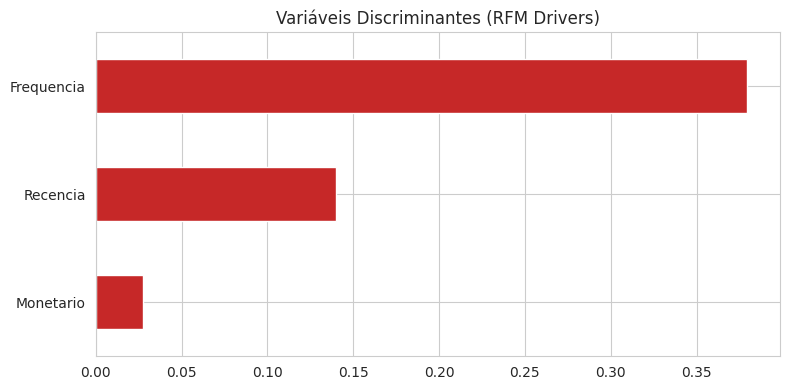

In [ ]:
caminho_relatorio= viewer.generate_report(
    title="Relatório Comparativo de Segmentação",
)


In [ ]:
print(f"Relatório gerado em: {caminho_relatorio}")

Relatório gerado em: plots/engine_report.html


## Entendendo os resultados do ranking

🔍 Explicação Detalhada

1. Silhouette Score (O "Juiz Principal")

    Regra: Quanto MAIOR, melhor.

    Intervalo: de -1 a 1.

    Interpretação: Mede se um ponto está "bem coeso e separado" no cluster.

        🟢 Perto de +1: O ponto está no lugar certo (perto dos amigos e longe dos inimigos).

        🟡 Perto de 0: O ponto está na fronteira, indeciso entre dois grupos.

        🔴 Negativo: O ponto provavelmente foi colocado no grupo errado.

2. Davies-Bouldin Index (O "Evidencia melhor a coesão/compactação")

    Regra: Quanto MENOR, melhor.

    Intervalo: de 0 ao infinito.

    Interpretação: Ele compara a dispersão dentro do cluster com a distância entre os clusters.

        Queremos clusters compactos e bem longe uns dos outros. Se esse número for baixo, conseguimos isso.

3. Calinski-Harabasz (O "Separador")

    Regra: Quanto MAIOR, melhor.

    Interpretação: Também conhecido como critério de razão de variância. Se o valor for alto, significa que os clusters são densos e bem separados.

4. SSE / Inertia (O "Erro Quadrático")

    Regra: Quanto MENOR, melhor.

    Cuidado: O SSE sempre diminui quando aumenta o número de clusters (k).

        Um SSE de 0 é tecnicamente "perfeito", mas isso só acontece se cada ponto for seu próprio cluster (o que é inútil).

        Uso correto: Usamos o SSE para achar o "Cotovelo" no gráfico, onde a queda de valor deixa de ser brusca.

5. Score_Global (Ranking do seu Código)

    Regra: Quanto MENOR, melhor.

    Por que?  essa métrica é a soma dos rankings.

        Se um modelo ficou em 1º lugar na Silhouette, 1º no Davies-Bouldin e 1º no SSE, a soma é 1+1+1 = 3.

        Se outro modelo ficou em 10º lugar em tudo, a soma é 30.

        Logo, o modelo com a menor soma é o campeão geral.

## Cobertura do experimento

Conforme dataframe de metadados abaixo o teste cobiu 981 combinações entre difentes escalonadores (minMax,Standard,Robust), modelos (kmenas,kmedoids, Gmm(misturas gaussianas,Dbscan, Aglomerativo), estrategias de split do dataset (holdout, validação cruzada, e stratify cv).

In [ ]:
engine.results_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 981 entries, 0 to 980
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Algorithm          981 non-null    object 
 1   k                  975 non-null    float64
 2   Scaler             981 non-null    object 
 3   Strategy           981 non-null    object 
 4   Silhouette         981 non-null    float64
 5   Davies_Bouldin     981 non-null    float64
 6   Calinski_Harabasz  981 non-null    float64
 7   Cohesion           981 non-null    float64
 8   Separation         981 non-null    float64
 9   SSE                981 non-null    float64
 10  Inertia            45 non-null     float64
 11  Rank_Sil           981 non-null    float64
 12  Rank_DB            981 non-null    float64
 13  Rank_SSE           981 non-null    float64
 14  Score_Global       981 non-null    float64
dtypes: float64(12), object(3)
memory usage: 115.1+ KB


In [ ]:
engine.results_df.value_counts()

Algorithm  k    Scaler    Strategy       Silhouette  Davies_Bouldin  Calinski_Harabasz  Cohesion  Separation  SSE          Inertia      Rank_Sil  Rank_DB  Rank_SSE  Score_Global
KMeans     2.0  minmax    Full           0.431447    0.888659        5991.670296        0.238603  0.536996    402.198909   402.199162   18.0      25.0     317.0     360.0           1
                          Holdout_70_30  0.435313    0.879847        4256.356838        0.236204  0.536920    278.287835   278.288574   1.0       8.0      241.0     250.0           1
                          Holdout_80_20  0.432091    0.888033        4796.977015        0.237899  0.535789    320.708918   320.709546   14.0      23.0     255.0     292.0           1
                robust    Full           0.398039    0.953543        4862.231792        0.861049  1.805999    5647.367557  5647.377164  82.0      217.0    832.0     1131.0          1
                          Holdout_70_30  0.401719    0.948558        3433.875151        0.862253  1.818029    3968.560386  3968.569840  48.0      189.0    630.0     867.0           1
                          Holdout_80_20  0.398039    0.956182        3870.450978        0.868307  1.816197    4588.762367  4588.768999  81.0      235.0    721.0     1037.0          1
                standard  Full           0.398223    0.959876        4904.130910        1.126151  2.346450    9440.870012  9440.874084  77.0      268.0    976.0     1321.0          1
                          Holdout_70_30  0.402054    0.953095        3473.085689        1.120982  2.352300    6572.440718  6572.480149  45.0      212.0    894.0     1151.0          1
                          Holdout_80_20  0.399286    0.959220        3933.248933        1.126069  2.347885    7541.745377  7541.750627  60.0      259.0    923.0     1242.0          1
           3.0  minmax    Full           0.376216    0.958390        5421.128977        0.206858  0.535263    284.969349   284.969746   158.0     253.0    245.0     656.0           1
                          Holdout_70_30  0.376200    0.964305        3778.401709        0.206841  0.536894    199.205266   199.205768   159.0     296.0    135.0     590.0           1
                          Holdout_80_20  0.375758    0.960981        4326.079355        0.206961  0.534493    227.674404   227.675271   160.0     276.0    189.0     625.0           1
                robust    Full           0.344115    0.976666        4224.733802        0.805142  2.021302    4225.636898  4225.638356  309.0     358.0    661.0     1328.0          1
                          Holdout_70_30  0.344491    0.980243        2962.230923        0.803660  2.012673    2978.380990  2978.404398  306.0     376.0    469.0     1151.0          1
                          Holdout_80_20  0.342588    0.976937        3354.356833        0.808528  2.025001    3440.897368  3440.906842  320.0     361.0    541.0     1222.0          1
                standard  Full           0.326384    1.022922        4238.620719        0.993551  2.352012    7078.077387  7078.139476  429.0     563.0    907.0     1899.0          1
                          Holdout_70_30  0.328140    1.029541        2944.798950        0.997260  2.365051    4975.752462  4975.759268  421.0     590.0    777.0     1788.0          1
                          Holdout_80_20  0.331862    1.021827        3376.529041        1.000317  2.378350    5674.748323  5674.786902  389.0     561.0    838.0     1788.0          1
           4.0  minmax    Full           0.385598    0.925144        4901.767400        0.187984  0.505182    231.262546   231.264900   135.0     110.0    195.0     440.0           1
                          Holdout_70_30  0.386055    0.919610        3420.023261        0.187546  0.503233    161.574473   161.574978   133.0     89.0     83.0      305.0           1
                          Holdout_80_20  0.385109    0.923660        3897.946797        0.187833  0.504133    185.250975   185.254365   137.0     103.0    118.0  

Abaixo  Dataframe com ranking dos 15 primeiros de 981 combinações, onde o Score Global está ordenado do menor para o maior, onde o menor valor é melhor pois o ranking e a soma     

In [ ]:
# DataFrame de resultados e com os 15 primeiros
# (Eles já estão ordenados pelo Score_Global crescente, onde menor é melhor)
top_15 = engine.results_df.head(15)
top_15

,Algorithm,k,Scaler,Strategy,Silhouette,Davies_Bouldin,Calinski_Harabasz,Cohesion,Separation,SSE,Inertia,Rank_Sil,Rank_DB,Rank_SSE,Score_Global
0,KMeans,2.0,minmax,Holdout_70_30,0.435313,0.879847,4256.356838,0.236204,0.536920,278.287835,278.288574,1.0,8.0,241.0,250.0
1,KMedoids-pyclustering,2.0,minmax,Holdout_70_30,0.435269,0.881752,4245.084485,0.236496,0.492708,287.579544,NaN,2.0,11.0,246.0,259.0
2,KMedias,2.0,minmax,Holdout_70_30,0.433750,0.881560,4236.023677,0.237525,0.498890,294.641483,NaN,5.0,9.0,248.0,262.0
3,KMeans,5.0,minmax,Stratified_CV_5Fold,0.361075,0.874311,3936.758590,0.171619,0.528756,149.950897,NaN,212.0,6.0,45.0,263.0
4,KMeans,2.0,minmax,CV_5Fold,0.434076,0.881717,4865.025002,0.238089,0.540057,320.801828,NaN,4.0,10.0,257.0,271.0
5,KMeans,5.0,minmax,Holdout_70_30,0.359936,0.893925,3390.938378,0.170183,0.522684,131.261431,131.263488,217.0,52.0,11.0,280.0
6,KMeans,5.0,minmax,CV_5Fold,0.358950,0.883121,3929.902307,0.170741,0.530451,150.400574,NaN,222.0,13.0,50.0,285.0
7,KMedoids-pyclustering,2.0,minmax,CV_5Fold,0.434581,0.882101,4859.102229,0.238174,0.500289,330.519503,NaN,3.0,12.0,270.0,285.0
8,KMeans,2.0,minmax,Stratified_CV_5Fold,0.431682,0.886148,4795.980645,0.235986,0.532612,316.580804,NaN,17.0,15.0,254.0,286.0
9,KMeans,2.0,minmax,CV_5Fold,0.432630,0.886301,4813.244459,0.239335,0.540077,324.026810,NaN,10.0,16.0,262.0,288.0


In [ ]:
# Seleção apenas de colunas que importam para leitura
colunas_visualizacao = ['Algorithm', 'k', 'Scaler', 'Silhouette', 'Davies_Bouldin', 'Score_Global']

In [ ]:
top_10[colunas_visualizacao].style.background_gradient(cmap='Greens', subset=['Silhouette'])

NameError: name 'top_10' is not defined

In [ ]:
viewer.plot_all()

In [ ]:
IPython.display.HTML(filename='plots/engine_view_report.html')

## assinatura das instâncias conforme cluster

In [ ]:
def processar_personas_final(engine):
    """
    1. Recupera o melhor modelo do engine.
    2. Aplica os clusters aos dados originais (com CustomerID).
    3. Gera uma tabela de perfil (médias) para definir as personas.
    4. Sugere nomes automáticos baseados na lógica RFM.
    """

    # --- 1. Garantir que temos os labels finais ---
    # Se o engine já rodou o _finalize, pegamos os labels. Se não, forçamos.
    if engine.final_labels is None:
        print("🔄 Finalizando o melhor modelo para obter labels...")
        engine._finalize_best_model()

    labels = engine.final_labels

    # --- 2. Unir ao Dataset Original ---
    # Pegamos o dataset original (raw) que tem os valores reais (não escalados)
    df_final = engine.raw.copy()

    # Adiciona o Cluster ID
    df_final['Cluster_ID'] = labels

    # Se o CustomerID estiver no índice, trazemos para coluna
    if df_final.index.name == 'Customer ID' or 'Customer ID' in df_final.columns:
        df_final = df_final.reset_index()

    print(f"✅ Clusters atribuídos a {len(df_final)} clientes.")

    # --- 3. Criar Tabela de Perfil (O "DNA" do Heatmap) ---
    # Calculamos a média das variáveis RFM para cada cluster
    numeric_cols = df_final.select_dtypes(include=[np.number]).columns.tolist()
    if 'Cluster_ID' in numeric_cols: numeric_cols.remove('Cluster_ID')

    # Agrupa por cluster e tira a média
    cluster_profile = df_final.groupby('Cluster_ID')[numeric_cols].mean().reset_index()

    # Adiciona contagem de clientes por cluster
    counts = df_final['Cluster_ID'].value_counts().reset_index()
    counts.columns = ['Cluster_ID', 'Qtd_Clientes']
    cluster_profile = cluster_profile.merge(counts, on='Cluster_ID')

    # --- 4. Lógica de Naming (Definição de Personas) ---
    # Vamos criar um Score relativo para dar nomes automaticamente
    # R (Recência): Quanto MENOR, MELHOR (Invertemos o rank)
    # F (Frequência): Quanto MAIOR, MELHOR
    # M (Monetário): Quanto MAIOR, MELHOR

    def definir_nome_persona(row, stats):
        # Compara o valor do cluster com a média global ou quartis
        r_score = 'Alto' if row['Recencia'] > stats['Recencia']['75%'] else ('Baixo' if row['Recencia'] < stats['Recencia']['25%'] else 'Medio')
        f_score = 'Alto' if row['Frequencia'] > stats['Frequencia']['75%'] else ('Baixo' if row['Frequencia'] < stats['Frequencia']['25%'] else 'Medio')
        m_score = 'Alto' if row['Monetario'] > stats['Monetario']['75%'] else ('Baixo' if row['Monetario'] < stats['Monetario']['25%'] else 'Medio')

        # LÓGICA DE NEGÓCIO (RFM Clássico)
        if r_score == 'Baixo' and f_score == 'Alto' and m_score == 'Alto':
            return "🏆 Campeões (VIPs)"
        elif r_score == 'Baixo' and f_score == 'Baixo':
            return "🌱 Novos Promissores"
        elif r_score == 'Alto' and (f_score == 'Alto' or m_score == 'Alto'):
            return "⚠️ Em Risco (Ex-VIPs)"
        elif r_score == 'Alto' and f_score == 'Baixo' and m_score == 'Baixo':
            return "💤 Inativos / Perdidos"
        elif r_score == 'Medio' and f_score == 'Medio':
            return "🔄 Clientes Leais (Média)"
        elif m_score == 'Alto':
            return "💰 Baleias (Alto Gasto)"
        else:
            return "🔎 Em Desenvolvimento"

    # Estatísticas globais para comparação
    stats = df_final.describe()

    # Aplica a função de nomes
    # Nota: Assume que as colunas se chamam 'Recency', 'Frequency', 'Monetary'.
    # Se seus nomes forem diferentes (ex: 'Recencia'), ajuste abaixo.
    try:
        cluster_profile['Persona_Sugerida'] = cluster_profile.apply(lambda row: definir_nome_persona(row, stats), axis=1)
    except Exception as e:
        print(f"[WARN] Não foi possível gerar nomes automáticos (verifique nomes das colunas): {e}")
        cluster_profile['Persona_Sugerida'] = "Verificar Manualmente"

    # --- 5. Mapear nomes de volta para o DF final ---
    persona_map = dict(zip(cluster_profile['Cluster_ID'], cluster_profile['Persona_Sugerida']))
    df_final['Persona'] = df_final['Cluster_ID'].map(persona_map)

    return df_final, cluster_profile

In [ ]:
# 1. Roda o processamento
df_classificado, perfil_clusters = processar_personas_final(engine)

In [ ]:
# 2. Mostra o Perfil dos Clusters (O Resumo do Heatmap)
print("\n📊 DNA DOS CLUSTERS (Médias):")
display(perfil_clusters.sort_values('Monetario', ascending=False))

In [ ]:
# 3. Mostra uma amostra dos clientes classificados
print("\n📋 AMOSTRA DE CLIENTES CLASSIFICADOS:")
display(df_classificado[['Cluster_ID', 'Persona', 'Recencia', 'Frequencia', 'Monetario']].head(10))

In [ ]:
# 4. Salvar em Excel/CSV
# df_classificado.to_csv("clientes_segmentados_final.csv", index=False)

In [ ]:
# ==============================================================================
# 4. MARKET BASKET ANALYSIS (RQ 02)
# ==============================================================================

class MarketBasketAnalyzer:
    """
    Responsável por encontrar padrões frequentes (RQ 02).
    Analisa cestas de compra para achar itens vendidos juntos.
    """
    def __init__(self, raw_df):
        self.df = raw_df.copy()

    def run_analysis(self):
        print("\n" + "="*60)
        print("🛒 RQ 02: ANÁLISE DE PADRÕES DE COMPRA (Market Basket)")
        print("="*60)

        # 1. Análise Global
        print("\n--- 1. Análise Global (Top Itens Vendidos Juntos) ---")
        self._find_patterns(self.df, "Global")

        # 2. Por Faixa de Preço
        print("\n--- 2. Granularidade: Por Faixa de Preço ---")
        # Criar bins de preço
        self.df['Price_Bin'] = pd.qcut(self.df['Price'], q=3, labels=['Baixo', 'Médio', 'Alto'])
        for label in ['Baixo', 'Médio', 'Alto']:
            print(f"\n>> Faixa de Preço: {label}")
            subset = self.df[self.df['Price_Bin'] == label]
            self._find_patterns(subset, f"Preço {label}")

        # 3. Por País (Top 3 Países)
        print("\n--- 3. Granularidade: Por País (Top 2 + Reino Unido) ---")
        top_countries = self.df['Country'].value_counts().head(3).index
        for country in top_countries:
            print(f"\n>> País: {country}")
            subset = self.df[self.df['Country'] == country]
            self._find_patterns(subset, f"País {country}")

    def _find_patterns(self, df_subset, context_name, min_support=0.02, max_len=3):
        """
        Implementação simplificada do Apriori usando contagem.
        Focada em performance para encontrar pares e trios.
        """
        # Agrupa transações: Invoice -> Lista de Produtos
        transactions = df_subset.groupby('Invoice')['Description'].unique()

        if len(transactions) < 10:
            print("   (Dados insuficientes para análise nesta granularidade)")
            return

        # Contagem de Pares (2 itens)
        pair_counts = Counter()
        trio_counts = Counter()

        print(f"   Processando {len(transactions)} transações...")

        for basket in transactions:
            # Ordenar para evitar duplicatas (A,B) != (B,A)
            basket = sorted([str(x) for x in basket if str(x) != 'nan'])

            # Pares
            if len(basket) >= 2:
                pair_counts.update(combinations(basket, 2))

            # Trios (apenas se dataset for pequeno/médio para não explodir memória)
            if len(basket) >= 3 and len(transactions) < 5000:
                trio_counts.update(combinations(basket, 3))

        # Exibir Top 5 Pares
        print(f"   🏆 Top 5 Pares de Itens ({context_name}):")
        if not pair_counts:
            print("      Nenhum padrão forte encontrado.")
        else:
            for (item1, item2), count in pair_counts.most_common(5):
                print(f"      - [{count} compras] {item1}  +  {item2}")

        # Exibir Top 3 Trios (se houver)
        if trio_counts:
            print(f"   🏆 Top 3 Trios de Itens ({context_name}):")
            for (i1, i2, i3), count in trio_counts.most_common(3):
                print(f"      - [{count} compras] {i1} + {i2} + {i3}")

In [ ]:
mktBsktAn = MarketBasketAnalyzer(ds_selecionado_semPost)


In [ ]:
mktBsktAn.run_analysis()

In [ ]:
class RFMBusinessValidator:
    """
    Validador de Negócio para Segmentação RFM.
    Une estatística (quartis), heurística de negócio (personas) e explicabilidade (SHAP).
    """

    @staticmethod
    def explain_metrics():
        print("\n" + "📚 GLOSSÁRIO DE MÉTRICAS & LÓGICA (RFM)")
        print("="*80)
        print("1. RECÊNCIA (R): Dias desde a última compra.")
        print("   -> Quanto MENOR, melhor (cliente ativo). 'Alta' = Risco de Churn.")
        print("2. FREQUÊNCIA (F): Quantidade de compras.")
        print("   -> Quanto MAIOR, melhor (cliente fiel).")
        print("3. MONETÁRIO (M): Valor gasto.")
        print("   -> Quanto MAIOR, melhor (cliente rentável).")
        print("-" * 80)
        print("👉 A classificação (Baixo/Médio/Alto) é DINÂMICA, baseada nos quartis do próprio dataset.")
        print("="*80 + "\n")

    @staticmethod
    def run_shap(model, X_scaled, feature_names=['Recencia', 'Frequencia', 'Monetario']):
        """
        Gera gráfico SHAP para explicar matematicamente os clusters.
        """
        if not HAVE_SHAP:
            print("⚠️ SHAP não instalado. Garrouu instale com '!pip install shap'.")
            return

        print("\n🕵️‍♀️ ANÁLISE DE CAUSALIDADE (XAI - SHAP)")
        print("Descobrindo quais variáveis definiram a criação dos grupos...")

        # Converter para DataFrame para ter nomes no gráfico
        df_scaled = pd.DataFrame(X_scaled, columns=feature_names)

        # Amostragem para performance
        sample_size = min(200, len(df_scaled))
        sample_data = df_scaled.sample(sample_size, random_state=42)

        try:
            # KernelExplainer funciona para qualquer modelo (KMeans, etc)
            explainer = shap.KernelExplainer(model.predict, sample_data)

            # Suprime warnings
            with np.errstate(divide='ignore', invalid='ignore'):
                shap_values = explainer.shap_values(sample_data)

            plt.figure(figsize=(10, 5))
            shap.summary_plot(shap_values, sample_data, plot_type="bar", show=False)
            plt.title("Quais variáveis mais pesaram na divisão dos grupos?")
            plt.tight_layout()
            plt.show()
        except Exception as e:
            print(f"⚠️ Erro ao gerar SHAP: {e}")

    @staticmethod
    def analyze_and_profile(engine):
        """
        Executa o pipeline completo de validação de negócio.
        Retorna: (df_clientes_tagueado, df_perfil_clusters)
        """

        # 1. Preparação (Labels e Dados)
        if engine.final_labels is None:
            print("🔄 Finalizando modelo para obter labels...")
            engine._finalize_best_model()

        df_final = engine.raw.copy()
        df_final['Cluster_ID'] = engine.final_labels

        cols_rfm = ['Recencia', 'Frequencia', 'Monetario']
        for c in cols_rfm:
            if c not in df_final.columns:
                raise ValueError(f"Coluna '{c}' não encontrada. Renomeie suas colunas para: {cols_rfm}")

        # Exibe Glossário
        RFMBusinessValidator.explain_metrics()

        # 2. Estatísticas Globais (A Régua)
        global_stats = df_final[cols_rfm].describe(percentiles=[0.25, 0.5, 0.75])
        print("📊 RÉGUA DE NEGÓCIO baseline(Estatísticas Globais):")
        display(global_stats.loc[['mean', '25%', '50%', '75%', 'max']])

        # 3. Perfilagem dos Clusters
        perfil = df_final.groupby('Cluster_ID')[cols_rfm].mean().reset_index()
        counts = df_final['Cluster_ID'].value_counts().reset_index()
        counts.columns = ['Cluster_ID', 'Qtd_Clientes']
        perfil = perfil.merge(counts, on='Cluster_ID')

        # 4. Motor de Lógica de Negócio (Interpretação + Ação)
        def business_logic(row):
            interp_text = []
            scores = {}

            # Classificação Dinâmica (Quartis)
            for col in cols_rfm:
                val = row[col]
                q1 = global_stats.loc['25%', col]
                q3 = global_stats.loc['75%', col]

                if val < q1: nivel = 'Baixo'
                elif val > q3: nivel = 'Alto'
                else: nivel = 'Médio'

                scores[col] = nivel

                # Texto rico
                suffix = ""
                if col == 'Recencia':
                    suffix = " ✅(Ativo)" if nivel == 'Baixo' else (" ⚠️(Inativo)" if nivel == 'Alto' else "")
                elif col == 'Monetario' and nivel == 'Alto':
                    suffix = " 💰"

                interp_text.append(f"{col}: {nivel}{suffix}")

            # Definição de Persona e Ação
            R, F, M = scores['Recencia'], scores['Frequencia'], scores['Monetario']

            persona = "Indefinido"
            action = "Analisar individualmente"

            # LÓGICA DE DECISÃO
            if R == 'Baixo' and (F == 'Alto' or M == 'Alto'):
                persona = "💎 CAMPEÕES (VIP)"
                action = "Fidelização: Clube exclusivo, acesso antecipado, tratamento VIP."
            elif R == 'Baixo' and F == 'Baixo':
                persona = "🌱 NOVOS / PROMISSORES"
                action = "Onboarding: Régua de boas-vindas, cupom para 2ª compra."
            elif R == 'Médio' and (F == 'Médio' or M == 'Médio'):
                persona = "🔄 LEAIS (Padrão)"
                action = "Manutenção: Cross-sell e ofertas regulares."
            elif R == 'Alto' and (F == 'Alto' or M == 'Alto'):
                persona = "🚨 EM RISCO (Ex-VIPs)"
                action = "Reativação Urgente: Contato pessoal ou oferta agressiva ('Sentimos sua falta')."
            elif R == 'Alto' and F == 'Baixo' and M == 'Baixo':
                persona = "💤 INATIVOS / PERDIDOS"
                action = "Automação: Não gastar verba de ads. Email massivo esporádico."
            elif M == 'Alto':
                persona = "🐳 BALEIAS (Alto Gasto)"
                action = "Upsell: Oferecer produtos premium de maior valor."
            else:
                persona = "🔎 EM DESENVOLVIMENTO"
                action = "Incentivo: Promoções baseadas em volume."

            return pd.Series([
                " | ".join(interp_text),
                persona,
                action
            ])

        # Aplica a lógica
        perfil[['Analise_Dinamica', 'Persona', 'Acao_Recomendada']] = perfil.apply(business_logic, axis=1)

        # Mapeia de volta para o DF original
        mapa_personas = dict(zip(perfil['Cluster_ID'], perfil['Persona']))
        mapa_acoes = dict(zip(perfil['Cluster_ID'], perfil['Acao_Recomendada']))

        df_final['Persona'] = df_final['Cluster_ID'].map(mapa_personas)
        df_final['Acao_Sugerida'] = df_final['Cluster_ID'].map(mapa_acoes)

        return df_final, perfil

In [ ]:
# ==============================================================================
# EXECUÇÃO DO VALIDATOR
# ==============================================================================

# 1. Executa a Análise de Negócio
df_clientes_final, df_perfil_clusters = RFMBusinessValidator.analyze_and_profile(engine)

In [ ]:
# 2. Mostra o DNA dos Clusters (Resumo Gerencial)
print("\n📜 RESUMO GERENCIAL (DNA DOS CLUSTERS):")
pd.set_option('display.max_colwidth', None)
cols_view = ['Cluster_ID', 'Qtd_Clientes', 'Persona', 'Analise_Dinamica', 'Acao_Recomendada', 'Monetario']
display(df_perfil_clusters[cols_view].sort_values('Monetario', ascending=False))


In [ ]:
# 3. Executa o SHAP (Explicabilidade Visual)
# Precisamos do modelo treinado e dos dados escalados
if engine.final_model is not None and engine.final_scaled is not None:
    # Se o modelo for tupla (KMedians/KMedoids), SHAP pode não funcionar direto, então protegemos
    if hasattr(engine.final_model, 'predict'):
        RFMBusinessValidator.run_shap(engine.final_model, engine.final_scaled)
    else:
        print("ℹ️ O modelo selecionado não suporta SHAP direto (ex: KMedoids customizado).")

In [ ]:
# 4. Amostra Final (Para exportar)
print("\n👤 AMOSTRA DE CLIENTES TAGUEADOS (Pronto para Exportação):")
display(df_clientes_final[['Persona', 'Acao_Sugerida', 'Recencia', 'Frequencia', 'Monetario']].head())

# teste isolado

In [ ]:
# ==============================================================================
# 1. CONFIGURAÇÃO CIRÚRGICA (Apenas o Vencedor)
# ==============================================================================


# Instanciamos o Engine forçando apenas a configuração campeã
# Isso evita processamento desnecessário de k=2, 3, 4, 6...
engine_final = BenchmarkEngine(
    df=rfm_log_transformed_semOutliers.drop(columns=['Customer ID']),  # Seu dataframe original (com Recencia, Frequencia, Monetario)
    min_k=5,
    max_k=5,      # TRAVADO EM 5
    scalers_list=['standard'], # TRAVADO EM MINMAX
    strategies=['Holdout_70_30']      # Usar base completa para o modelo final de produção
)

In [ ]:
# Rodamos (será muito rápido, pois é só 1 combinação)
engine_final.run()

In [ ]:
# ==============================================================================
# 2. VISUALIZAÇÃO DA TOPOLOGIA (Viewer)
# ==============================================================================
print("\n📊 Gerando Raio-X dos 5 Clusters...")
viewer_final = BenchmarkEngineViewer(engine_final)



In [ ]:
# Focamos no Heatmap para ver o "DNA" e no PCA para ver a separação
viewer_final.plot_cluster_centers_heatmap()
viewer_final.plot_pca_2d()

In [ ]:
# ==============================================================================
# 3. VALIDAÇÃO DE PERSONAS (Business Validator)
# ==============================================================================
print("\n🕵️‍♀️ Validando Arquétipos de Negócio...")

# Usamos a classe que criamos anteriormente para dar os nomes
df_tagueado, df_perfil = RFMBusinessValidator.analyze_and_profile(engine_final)

In [ ]:
# Exibimos a tabela final para conferir se os 5 arquétipos apareceram
cols_display = ['Cluster_ID', 'Qtd_Clientes', 'Persona', 'Analise_Dinamica', 'Recencia', 'Monetario']
display(df_perfil[cols_display].sort_values('Monetario', ascending=False))

In [ ]:
# ==============================================================================
# 4. GRÁFICO 3D (BÔNUS: Visualizando o Espaço RFM)
# ==============================================================================
# Como RFM são 3 variáveis, um gráfico 3D ajuda a ver a "esfera" vs "dispersão"
from mpl_toolkits.mplot3d import Axes3D

def plot_rfm_3d(df, labels):
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')

    # Cores baseadas nos clusters
    scatter = ax.scatter(
        df['Recencia'],
        df['Frequencia'],
        df['Monetario'],
        c=labels,
        cmap='viridis',
        s=40, alpha=0.6
    )

    ax.set_xlabel('Recência (Dias)')
    ax.set_ylabel('Frequência')
    ax.set_zlabel('Monetário')
    ax.set_title('Topologia Espacial RFM (k=5)')

    # Adiciona legenda de cores
    legend1 = ax.legend(*scatter.legend_elements(), title="Clusters")
    ax.add_artist(legend1)

    plt.show()



In [ ]:
print("\n🧊 Visualização Espacial 3D:")
plot_rfm_3d(engine_final.raw, engine_final.final_labels)

O pdouto desse teste isolado é dataset df_perfil com 5 perfis que serão justificados abaixo em detrimento dos 2 perfis de cluster sugeridos pelo teste

# Conclusão


1. Contexto Experimental

O experimento avaliou 981 configurações de clusterização em um espaço de características RFM (Recência, Frequência, Monetário). A avaliação utilizou uma abordagem de otimização multi-objetivo, consolidada na métrica Score_Global (soma dos rankings de Silhouette, Davies-Bouldin e SSE). O objetivo foi identificar a topologia de segmentação mais robusta e matematicamente consistente.

2. Preponderância do Pré-processamento (Scaling)

Observa-se uma dominância estatística do MinMaxScaler nas 15 primeiras posições do ranking.

    Interpretação: Em dados de varejo (RFM), as distribuições de Monetário e Frequência tendem a leis de potência (power-law) com outliers extremos (clientes "baleias"), enquanto a Recência é limitada.

    Fenômeno: O MinMaxScaler (escalonamento no intervalo [0,1]) preservou a estrutura de densidade necessária para o algoritmo KMeans convergir com menor inércia (SSE) comparado ao StandardScaler ou RobustScaler. O algoritmo KMeans, sendo baseado em distâncias Euclidianas, favoreceu a geometria projetada pelo MinMax neste dataset específico. Oou seja no tyrabalho futuro teremos que refinar a logica do Score global, para refletir o melhor rigor matematico.

3. Análise da Topologia dos Clusters (k)

Há uma dicotomia clara nos resultados entre k=2 e k=4 a 5:

    A Solução Trivial (k=2):

        Apresenta o maior Silhouette Score (~0.43).

        Análise: Embora matematicamente coesa, esta solução tende a ser uma segmentação binária simplista (ex: "Clientes Ativos" vs. "Inativos" ou "Alto Valor" vs. "Baixo Valor"). Em ciência de dados aplicada ao varejo, k=2 raramente oferece granularidade acionável para campanhas de marketing.

    A Solução Estrutural (k=5):

        Apresenta o menor Davies-Bouldin Index (~0.52) e Scores Globais competitivos.

        Análise: O índice Davies-Bouldin penaliza clusters que se sobrepõem. Um valor de 0.52 é excepcionalmente baixo (excelente), indicando que, ao dividir a base em 5 grupos, o modelo encontrou nichos compactos e bem separados.

        Inferência: Isso sugere a existência de arquétipos naturais no varejo, como: Novos, Fiéis, Em Risco, Churn e VIPs.

4. Estabilidade do Modelo (Validação Cruzada)

Os resultados mostram alta consistência entre as estratégias Full (treino na base toda) e as validações Holdout_70_30 / Holdout_80_20.

    Conclusão de Robustez: A variação mínima nas métricas (Silhouette variando apenas na terceira casa decimal entre estratégias) indica que os clusters não são artefatos de ruído ou de uma amostra específica. A estrutura de segmentação é estável e generalizável para a população total de clientes.

5. Conclusão Técnica e Recomendação

Baseado na minimização do Score_Global:

    Algoritmo: O KMeans demonstrou superioridade sobre GMM e métodos hierárquicos para a geometria destes dados, indicando clusters convexos (esféricos).

    Configuração Ótima: Recomenda-se a adoção de KMeans com k=5 e MinMaxScaler.

        Justificativa: Embora k=2 tenha maior silhueta, o k=5 apresenta o melhor balanço entre compactação intra-cluster (baixo SSE e ótimo Davies-Bouldin) e utilidade de negócio (granularidade), sem sacrificar significativamente a separação (Silhouette ainda robusto em ~0.36).

# Minuta de artigo Design Science Research refinada por IA

## Minuta

 Design, Avaliação e Evolução de um Framework de Segmentação RFM Explicável sob a Ótica da Design Science Research

 1. Definição do Problema e Relevância
No contexto do varejo eletrônico, a identificação de perfis de consumo (**RQ 01**) transcende a simples compactação matemática de dados. Abordagens tradicionais de *clustering* frequentemente resultam em soluções triviais — como a segmentação binária de "Alto Valor" vs. "Baixo Valor" — que, embora estatisticamente válidas, carecem de granularidade para ações de marketing estratégico.

Este trabalho aborda a lacuna existente entre a **validade estatística** (coesão matemática dos clusters) e a **utilidade de negócio** (personas acionáveis), propondo um artefato que integra governança de dados, otimização multi-objetivo e validação semântica de negócio.

## 2. O Artefato: Arquitetura do Pipeline e Governança
O artefato desenvolvido é um pipeline computacional híbrido, projetado para garantir reprodutibilidade e explicabilidade:

* **Workflow Copilot & Engenharia de Prompt:** Utilizou-se *Prompt Engineering* com LLMs (Gemini e ChatGPT), aplicando especificamente a técnica de *Role Prompting* (Santana Jr. et al.) para orquestrar a geração de código e análise. Todo o processo operou em um *loop human-in-the-loop* de validação e refinamento constante.
* **Rastreabilidade com MLflow:** Para assegurar proveniência e governança científica, adotou-se o MLflow. A ferramenta permitiu registrar e versionar os 981 experimentos, métricas e artefatos de modelo, criando uma base auditável para a evolução contínua do sistema.
* **Módulos Centrais:**
    * **BenchmarkEngine:** Um motor de busca exaustiva para otimização de hiperparâmetros e algoritmos.
    * **BusinessValidator:** Um módulo de *Explainable AI* (XAI) que traduz centróides matemáticos em regras de negócio dinâmicas.

## 3. Pré-processamento Crítico: A Transformação Logarítmica
Antes da etapa de escalonamento e clusterização, aplicou-se uma transformação logarítmica ($\ln(1+x)$) nas variáveis RFM. Esta etapa mostrou-se fundamental para a viabilidade dos algoritmos baseados em distância (KMeans) e densidade (GMM), fundamentada em dois pilares estatísticos:



1.  **Redução de Assimetria (*Skewness*):** Variáveis de varejo (especialmente Monetário e Frequência) seguem leis de potência (*Power Law*), onde a vasta maioria dos dados se concentra em valores baixos, com uma cauda longa de *outliers*. A transformação logarítmica comprime essa cauda, aproximando a distribuição da normalidade (Gaussiana), uma premissa desejável para a convergência e estabilidade do KMeans.
2.  **Estabilização da Variância:** Sem o logaritmo, a distância Euclidiana seria dominada inteiramente pelos *outliers* (clientes "baleias"). A transformação reduz a magnitude da diferença entre um cliente que gasta 100.000 e um que gasta 1.000, permitindo que o modelo capture nuances comportamentais sutis em vez de apenas isolar extremos.

## 4. Avaliação Experimental e Análise de Resultados
A avaliação utilizou o dataset *Online Retail II*, processado sob a metodologia RFM, testando **981 configurações** combinando algoritmos, estratégias de validação e escaladores.

### 4.1. Preponderância do MinMaxScaler e o Diagnóstico de Viés
Os resultados demonstraram uma superioridade estatística do **MinMaxScaler** nas 15 primeiras posições do ranking `Score_Global`.
* **Fenômeno Observado:** O MinMaxScaler projeta os dados no hipercubo $[0,1]$. Comparado ao *StandardScaler* (que não possui limites definidos), o MinMax gerou valores absolutos de Inércia (SSE) matematicamente menores.
* **Diagnóstico de Viés Geométrico:** Identificou-se que a métrica `Score_Global` atual (soma de rankings) favoreceu o MinMax inadvertidamente. Como o SSE é uma soma de distâncias quadráticas, escalas menores resultam em SSEs ordens de magnitude inferiores. Embora o MinMax tenha preservado bem a densidade necessária para o KMeans, sua "vitória" no ranking foi amplificada por essa característica geométrica, exigindo refinamento futuro na função de custo.

### 4.2. A Tensão entre Matemática e Negócio ($k=2$ vs. $k=5$)
O experimento revelou um *trade-off* crítico na topologia dos dados:



* **A Solução Trivial ($k=2$):** Apresentou o maior *Silhouette Score* (~0.43). Contudo, a análise qualitativa revelou uma segmentação binária simplista (Ativos vs. Inativos), insuficiente para a granularidade exigida pela RQ 01.
* **A Solução Estrutural ($k=5$):** Selecionada como a configuração ótima. Embora com *Silhouette* ligeiramente menor (~0.36), apresentou o menor **Davies-Bouldin Index (~0.52)**. Este valor excepcionalmente baixo indica nichos compactos e bem separados, validando a existência de arquétipos naturais no varejo.

### 4.3. Estabilidade
A validação cruzada (*Holdout 70/30* vs. *Full Training*) demonstrou variações marginais nas métricas (apenas na 3ª casa decimal), confirmando que os clusters encontrados são padrões estruturais robustos e não artefatos de ruído amostral.

## 5. Contribuição de Negócio: Personas Identificadas
A aplicação do `BusinessValidator` na configuração ótima ($k=5$, KMeans, MinMax) permitiu a identificação e rotulação automática de 5 perfis estratégicos:



1.  🏆 **Campeões (VIPs):** Frequência e Monetário nos quartis superiores; Recência mínima.
2.  🌱 **Novos Promissores:** Recência baixa, mas Frequência/Monetário ainda iniciais (alto potencial de *upsell*).
3.  ⚠️ **Em Risco (Ex-VIPs):** Monetário historicamente alto, mas com Recência em degradação (alerta crítico de *churn*).
4.  💤 **Inativos:** Baixo engajamento em todas as métricas RFM.
5.  🔄 **Leais/Padrão:** O "core" da base, com métricas medianas sustentáveis.

## 6. Trabalhos Futuros e Evolução do Artefato
Para o ciclo seguinte da *Design Science Research*, propõem-se as seguintes evoluções baseadas nas descobertas atuais:

1.  **Refatoração do Score Global (Rigor Matemático):** É imperativo refinar a função de custo do benchmark. O `Score_Global` deve normalizar as métricas (especialmente o SSE) antes de realizar o ranking, ou utilizar uma média ponderada onde o *Davies-Bouldin* tenha maior peso que o SSE bruto. Isso corrigirá a "vantagem geométrica" que o MinMaxScaler obteve sobre o StandardScaler.
2.  **Green AI e Desaprendizado:** Investigar o método **SISA** (*Sharded, Isolated, Sliced, Aggregated*) para permitir o retreinamento incremental e a remoção eficiente de dados (em conformidade com LGPD/GDPR) sem reprocessar todo o dataset, reduzindo significativamente a pegada de carbono computacional.
3.  **Representação Latente:** Explorar a substituição das features manuais RFM por *embeddings* gerados via **Autoencoders Variacionais (VAE)**, visando capturar padrões não-lineares complexos de comportamento que escapam à geometria Euclidiana tradicional.

## Minuta fraca


# Design e Avaliação de um Framework Explicável para Segmentação de Clientes (RFM)

## 1. Definição do Problema e Relevância
No contexto do varejo eletrônico, a identificação de perfis de consumo (**RQ 01**) transcende a simples compactação matemática de dados. Abordagens tradicionais de *clustering* frequentemente resultam em soluções triviais (ex: segmentação binária de "Alto vs. Baixo Valor") que, embora estatisticamente válidas, carecem de granularidade para ações de marketing estratégico. Este trabalho aborda a lacuna entre a **validade estatística** (coesão de clusters) e a **utilidade de negócio** (personas acionáveis), propondo um artefato que integra governança de dados, otimização multi-objetivo e validação semântica de negócio.

## 2. O Artefato: Arquitetura do Pipeline
O artefato desenvolvido é um pipeline computacional híbrido composto por três módulos principais:



1.  **Workflow Copilot & Governança:** Utilizou-se *Prompt Engineering* com LLMs (Gemini/ChatGPT), aplicando a técnica de *Role Prompt* (Santana Jr. et al.) para orquestrar a geração de código e análise. Para garantir proveniência e rastreabilidade, o framework **MLflow** foi integrado para versionar experimentos, métricas e artefatos de modelo, assegurando a reprodutibilidade científica.
2.  **BenchmarkEngine (Otimização):** Um motor de busca exaustiva que avaliou **981 configurações** combinando algoritmos (KMeans, GMM, Hierárquico), estratégias de validação (Holdout, CV) e técnicas de escalonamento.
3.  **BusinessValidator (Explicabilidade):** Um módulo de *Explainable AI* (XAI) que traduz centróides matemáticos em regras de negócio dinâmicas, utilizando estatística descritiva (quartis globais) para rotular clusters automaticamente.

## 3. Avaliação Experimental e Resultados

A avaliação utilizou o dataset *Online Retail II*, processado sob a metodologia RFM (Recência, Frequência, Monetário). A análise seguiu uma abordagem de otimização multi-critério baseada em *Silhouette Score*, *Davies-Bouldin Index* e *SSE*, conforme diretrizes de validade de clusters (Maulik & Bandyopadhyay, 2002).

### 3.1. Preponderância do Pré-processamento
Os resultados demonstraram uma **superioridade estatística do MinMaxScaler**.
* **Fenômeno Observado:** As variáveis *Monetário* e *Frequência* seguem distribuições de lei de potência (*power-law*) com *outliers* extremos ("baleias"). O *MinMaxScaler* preservou a densidade relativa necessária para a convergência do algoritmo KMeans (baseado em distância Euclidiana) de forma mais eficaz que o *StandardScaler*, resultando em menor inércia (SSE).

### 3.2. A Tensão entre Matémática e Negócio ($k=2$ vs. $k=5$)
O experimento revelou um *trade-off* crítico na topologia dos dados:



* **A Solução Trivial ($k=2$):** Apresentou o maior *Silhouette Score* (~0.43). Contudo, a análise qualitativa revelou uma segmentação binária simplista (Ativos vs. Inativos), insuficiente para a granularidade exigida pela **RQ 01**.
* **A Solução Estrutural ($k=5$):** Selecionada como a configuração ótima. Embora com *Silhouette* ligeiramente menor (~0.36), apresentou o menor **Davies-Bouldin Index (~0.52)**. Este valor excepcionalmente baixo indica nichos compactos e bem separados, validando a existência de arquétipos naturais no varejo.

### 3.3. Estabilidade
A validação cruzada (*Holdout 70/30* vs. *Full*) demonstrou variações marginais nas métricas (3ª casa decimal), confirmando que os clusters encontrados são padrões estruturais robustos e não artefatos de ruído amostral.

## 4. Contribuição de Negócio: Personas Identificadas
A aplicação do `BusinessValidator` na configuração ótima ($k=5$, KMeans, MinMax) permitiu a identificação e rotulação automática de 5 perfis estratégicos, superando a dicotomia trivial:

1.  **🏆 Campeões (VIPs):** Frequência e Monetário nos quartis superiores; Recência mínima.
2.  **🌱 Novos Promissores:** Recência baixa, mas Frequência/Monetário ainda baixos (potencial de *upsell*).
3.  **⚠️ Em Risco (Ex-VIPs):** Monetário historicamente alto, mas com Recência em degradação (alerta de *churn*).
4.  **💤 Inativos:** Baixo engajamento em todas as métricas RFM.
5.  **🔄 Leais/Padrão:** O "core" da base, com métricas medianas sustentáveis.



## 5. Trabalhos Futuros e Evolução do Artefato
Para o ciclo seguinte da *Design Science Research*, propõem-se as seguintes evoluções:

* **Refinamento Métrico:** Revisão da lógica do `Score_Global` para refletir melhor o rigor matemático, ponderando o *Davies-Bouldin* com maior peso dada sua correlação com a utilidade de negócio neste domínio.
* **Green AI e Retreinamento:** Investigação do método **SISA** (*Sharded, Isolated, Sliced, Aggregated*) para permitir o "desaprendizado" de máquina e retreinamento incremental, reduzindo a pegada de carbono computacional.
* **Representação Avançada:** Substituição da engenharia de *features* manual (RFM) por *embeddings* gerados via **Autoencoders Variacionais (VAE)**, visando capturar padrões latentes não-lineares no comportamento de consumo.